**Section 1: IMPORT LIBRARIES**

In [ ]:
import os
import sys
import json
import glob
import random
import time
import platform
import subprocess
import warnings

import numpy as np
import pandas as pd
import cv2
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, auc as sk_auc,
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras import layers, Model, applications, optimizers, callbacks
from tensorflow.keras import mixed_precision

import shap

warnings.filterwarnings("ignore")

**Section 2: Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Section 3: Configuration**

In [ ]:
DATASET_DIR   = "/content/ISIC-images"
METADATA_PATH = "/content/drive/MyDrive/skin_cancer_project/metadata.csv"
OUTPUT_DIR    = "/content/drive/MyDrive/skin_cancer_project/outputs"

IMG_SIZE          = 224
BATCH_SIZE        = 64
EPOCHS_HEAD       = 10
EPOCHS_FINETUNE   = 20
LEARNING_RATE     = 1e-3
FINETUNE_LR       = 1e-5
NUM_CLASSES       = 7
RANDOM_SEED       = 42
TRAIN_RATIO       = 0.70
VAL_RATIO         = 0.15
TEST_RATIO        = 0.15

CLASS_NAMES  = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

DIAG3_TO_CLASS = {
    "Nevus":                         "nv",
    "Pigmented benign keratosis":    "bkl",
    "Melanoma, NOS":                 "mel",
    "Basal cell carcinoma":          "bcc",
    "Squamous cell carcinoma, NOS":  "akiec",
    "Solar or actinic keratosis":    "akiec",
    "Dermatofibroma":                "df",
}

DIAG2_FALLBACK_TO_CLASS = {
    "Benign soft tissue proliferations - Vascular": "vasc",
}

MALIGNANT_CLASSES = {"mel", "bcc", "akiec"}
BENIGN_CLASSES    = {"nv", "bkl", "df", "vasc"}

os.makedirs(OUTPUT_DIR, exist_ok=True)

**Section 4: Dataset Loading**

In [ ]:
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seeds(RANDOM_SEED)

df = pd.read_csv(METADATA_PATH)

required_cols = ["isic_id", "lesion_id", "diagnosis_1", "diagnosis_2", "diagnosis_3"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Metadata missing required columns: {missing_required}")

def derive_class(row):
    d3 = row.get("diagnosis_3")
    if isinstance(d3, str) and d3 in DIAG3_TO_CLASS:
        return DIAG3_TO_CLASS[d3]
    d2 = row.get("diagnosis_2")
    if isinstance(d2, str) and d2 in DIAG2_FALLBACK_TO_CLASS:
        return DIAG2_FALLBACK_TO_CLASS[d2]
    return None

df["class_label"] = df.apply(derive_class, axis=1)

unmapped = df["class_label"].isna().sum()
if unmapped > 0:
    df = df[df["class_label"].notna()].reset_index(drop=True)

**Section 5: Data Verification**

In [ ]:
all_image_paths = []
for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
    all_image_paths.extend(
        glob.glob(os.path.join(DATASET_DIR, "**", ext), recursive=True))

image_index = {}
for p in all_image_paths:
    stem = os.path.splitext(os.path.basename(p))[0]
    image_index.setdefault(stem, []).append(p)

def find_image_path(isic_id):
    stem = str(isic_id).strip()
    if stem in image_index:
        return image_index[stem][0]
    stem_no_ext = os.path.splitext(stem)[0]
    if stem_no_ext in image_index:
        return image_index[stem_no_ext][0]
    return None

df["image_path"] = df["isic_id"].astype(str).apply(find_image_path)

found_mask = df["image_path"].notna()
n_missing  = int((~found_mask).sum())

if n_missing > 0:
    df_missing = df[~found_mask].copy()
    df_missing.to_csv(os.path.join(OUTPUT_DIR, "missing_images.csv"), index=False)

df = df[found_mask].reset_index(drop=True)

**Section 6: Exploratory Data Analysis**

(11720, 20)
isic_id                    object
attribution                object
copyright_license          object
age_approx                float64
anatom_site_1              object
anatom_site_2              object
anatom_site_3              object
anatom_site_special        object
concomitant_biopsy           bool
diagnosis_1                object
diagnosis_2                object
diagnosis_3                object
diagnosis_confirm_type     object
image_manipulation         object
image_type                 object
lesion_id                  object
melanocytic                  bool
sex                        object
class_label                object
image_path                 object
dtype: object
image_manipulation        11719
anatom_site_special       11183
anatom_site_3              9038
anatom_site_2              5804
anatom_site_1               581
age_approx                  383
sex                         343
diagnosis_3                 180
image_type                    1
copyri

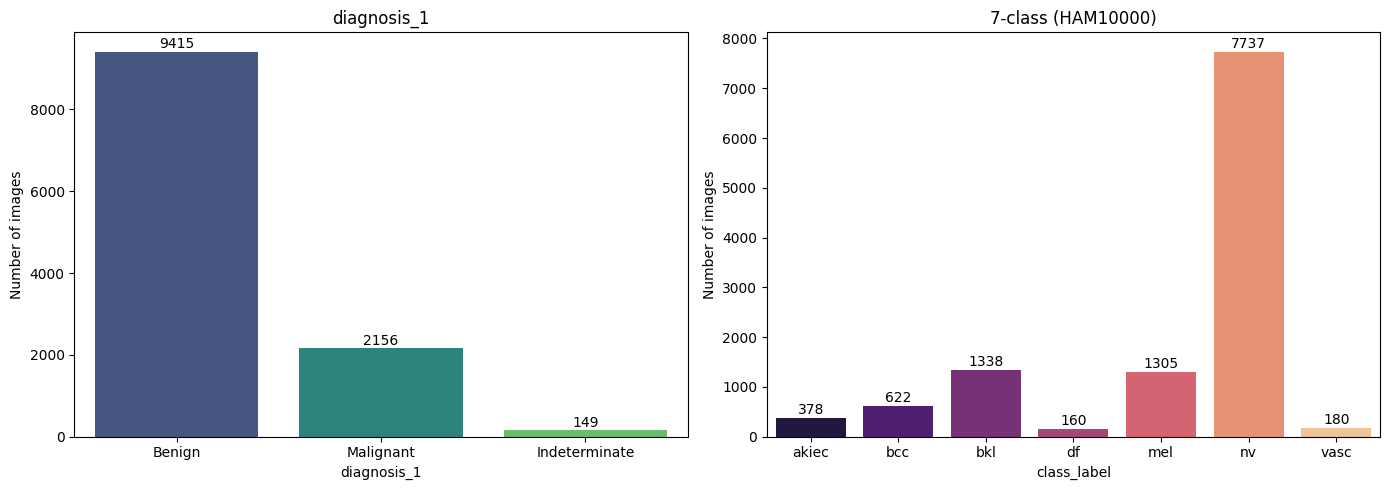

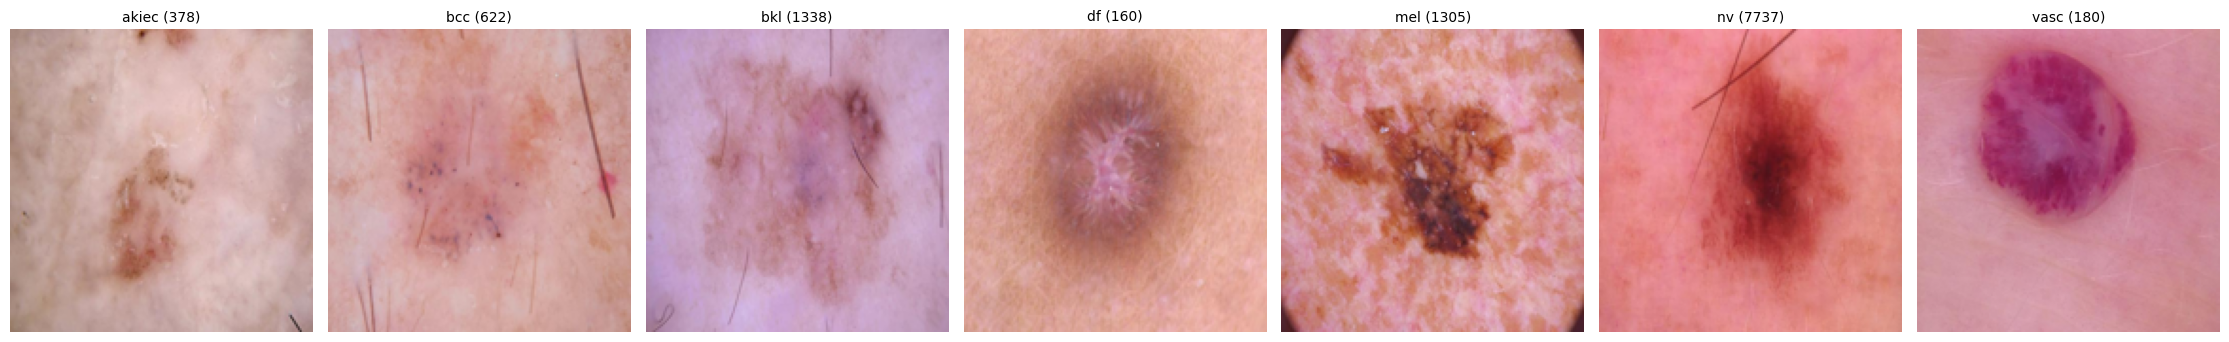

count    8838.000000
mean        1.326092
std         0.621755
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         6.000000
dtype: float64
2221 lesions with more than one image


In [ ]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum().sort_values(ascending=False))

d1_counts = df["diagnosis_1"].value_counts()
class_counts = df["class_label"].value_counts().reindex(CLASS_NAMES)
class_pct = (class_counts / len(df) * 100).round(2)

print(d1_counts)
print((d1_counts / len(df) * 100).round(2))
print(pd.DataFrame({"count": class_counts, "percent": class_pct}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=d1_counts.index, y=d1_counts.values, palette="viridis", ax=axes[0])
for i, v in enumerate(d1_counts.values):
    axes[0].text(i, v + max(d1_counts.values)*0.01, str(v), ha="center", fontsize=10)
axes[0].set_title("diagnosis_1")
axes[0].set_ylabel("Number of images")

sns.barplot(x=class_counts.index, y=class_counts.values, palette="magma", ax=axes[1])
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v + max(class_counts.values)*0.01, str(v), ha="center", fontsize=10)
axes[1].set_title("7-class (HAM10000)")
axes[1].set_ylabel("Number of images")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distributions.png"), dpi=150)
plt.show()

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(3.2 * NUM_CLASSES, 4))
for ax, cls in zip(axes, CLASS_NAMES):
    sample = df[df["class_label"] == cls].iloc[0]
    img = Image.open(sample["image_path"]).convert("RGB").resize((160, 160))
    ax.imshow(img)
    ax.set_title(f"{cls} ({class_counts[cls]})", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_images_7class.png"), dpi=150)
plt.show()

n_les = df["lesion_id"].nunique()
rows_per_lesion = df.groupby("lesion_id").size()
print(rows_per_lesion.describe())
print((rows_per_lesion > 1).sum(), "lesions with more than one image")

**Section 7: Train/Validation/Test Split**

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

lesion_class = (
    df.groupby("lesion_id")["class_label"]
      .agg(lambda s: s.value_counts().idxmax())
      .rename("lesion_class")
      .reset_index()
)

gss1 = GroupShuffleSplit(
    n_splits=1, test_size=(VAL_RATIO + TEST_RATIO), random_state=RANDOM_SEED)
train_idx, temp_idx = next(gss1.split(df, groups=df["lesion_id"]))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_temp  = df.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_SEED)
val_idx, test_idx = next(gss2.split(df_temp, groups=df_temp["lesion_id"]))

df_val  = df_temp.iloc[val_idx].reset_index(drop=True)
df_test = df_temp.iloc[test_idx].reset_index(drop=True)

print(df_train.shape, df_val.shape, df_test.shape)

s_tr = set(df_train["lesion_id"])
s_va = set(df_val["lesion_id"])
s_te = set(df_test["lesion_id"])
assert not (s_tr & s_va) and not (s_tr & s_te) and not (s_va & s_te)

dist = pd.DataFrame({
    "train":      df_train["class_label"].value_counts().reindex(CLASS_NAMES, fill_value=0),
    "validation": df_val["class_label"].value_counts().reindex(CLASS_NAMES, fill_value=0),
    "test":       df_test["class_label"].value_counts().reindex(CLASS_NAMES, fill_value=0),
})
print(dist)

d1 = pd.DataFrame({
    "train":      df_train["diagnosis_1"].value_counts(),
    "validation": df_val["diagnosis_1"].value_counts(),
    "test":       df_test["diagnosis_1"].value_counts(),
}).fillna(0).astype(int)
print(d1)

for name, part in [("train", df_train), ("val", df_val), ("test", df_test)]:
    part.assign(split=name).to_csv(
        os.path.join(OUTPUT_DIR, f"split_{name}.csv"), index=False)

(8190, 20) (1764, 20) (1766, 20)
             train  validation  test
class_label                         
akiec          271          61    46
bcc            442          82    98
bkl            925         193   220
df             129          10    21
mel            954         183   168
nv            5367        1185  1185
vasc           102          50    28
               train  validation  test
diagnosis_1                           
Benign          6523        1438  1454
Malignant       1558         303   295
Indeterminate    109          23    17


**Section 8: Image Preprocessing**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def _decode(path, label):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE],
                          method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def augment_train(img, label):
    img = tf.image.random_flip_left_right(img, seed=RANDOM_SEED)
    img = tf.image.random_flip_up_down(img, seed=RANDOM_SEED)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32, seed=RANDOM_SEED)
    img = tf.image.rot90(img, k=k)
    crop_side = int(IMG_SIZE * 0.90)
    img = tf.image.random_crop(img, size=[crop_side, crop_side, 3],
                               seed=RANDOM_SEED)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.random_brightness(img, max_delta=0.10, seed=RANDOM_SEED)
    img = tf.image.random_contrast(img, lower=0.90, upper=1.10,
                                   seed=RANDOM_SEED)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


def to_onehot(img, lbl):
    return img, tf.one_hot(lbl, NUM_CLASSES)


def make_fast_dataset(dataframe, batch_size, shuffle=False, augment=None):
    paths  = dataframe["image_path"].astype(str).values
    labels = dataframe["class_label"].map(CLASS_TO_IDX).astype(np.int32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(min(len(paths), 4000),
                        seed=RANDOM_SEED, reshuffle_each_iteration=True)

    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE, deterministic=False)

    if augment is not None:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE, deterministic=False)

    ds = ds.map(to_onehot, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_ds = make_fast_dataset(df_train, BATCH_SIZE, shuffle=True,  augment=augment_train)
val_ds   = make_fast_dataset(df_val,   BATCH_SIZE, shuffle=False, augment=None)
test_ds  = make_fast_dataset(df_test,  BATCH_SIZE, shuffle=False, augment=None)

**Section 9: Data Augmentation (train-only)**

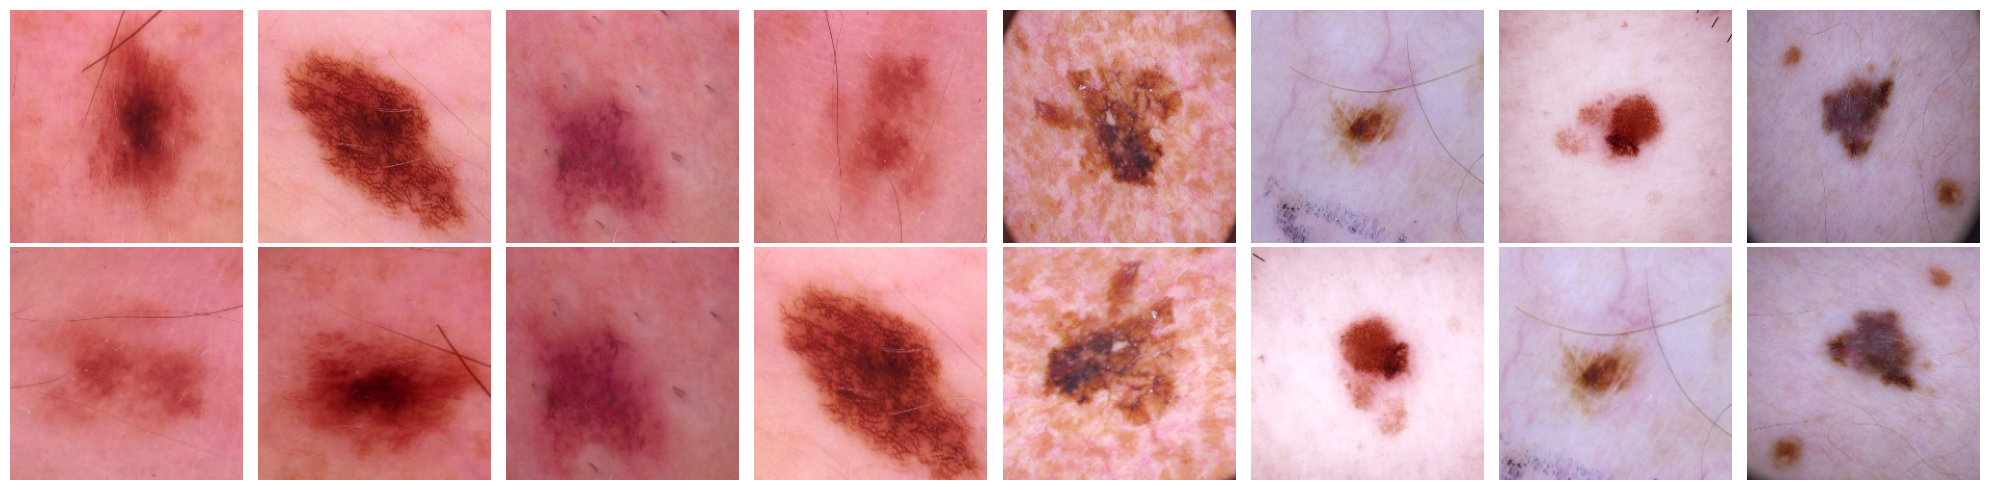

In [ ]:
imgs_clean = next(iter(make_fast_dataset(df_train, 8, shuffle=False, augment=None)))[0]
imgs_aug   = next(iter(make_fast_dataset(df_train, 8, shuffle=False, augment=augment_train)))[0]

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i in range(8):
    axes[0, i].imshow(imgs_clean[i].numpy()); axes[0, i].axis("off")
    axes[1, i].imshow(imgs_aug[i].numpy());   axes[1, i].axis("off")
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("augmented")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "augmentation_preview.png"), dpi=150)
plt.show()

**Section 10: Class Imbalance Handling**

In [ ]:
y_train_int = df_train["class_label"].map(CLASS_TO_IDX).values
classes_present = np.unique(y_train_int)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=y_train_int,
)
class_weight_dict = {int(c): float(w) for c, w in zip(classes_present, weights)}

for idx in range(NUM_CLASSES):
    print(f"{IDX_TO_CLASS[idx]:>6}  n={(y_train_int == idx).sum():5d}  weight={class_weight_dict.get(idx, 1.0):.4f}")


def focal_loss(gamma=2.0, alpha=None):
    alpha_t = tf.constant(alpha, dtype=tf.float32) if alpha is not None else None

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_factor = tf.pow(1.0 - p_t, gamma)
        loss_val = focal_factor * ce
        if alpha_t is not None:
            loss_val = loss_val * alpha_t
        return tf.reduce_mean(tf.reduce_sum(loss_val, axis=-1))
    return loss


alpha_arr = np.ones(NUM_CLASSES, dtype=np.float32)
for idx in range(NUM_CLASSES):
    alpha_arr[idx] = class_weight_dict.get(idx, 1.0)
alpha_arr = alpha_arr / alpha_arr.mean()

for idx in range(NUM_CLASSES):
    print(f"{IDX_TO_CLASS[idx]:>6} : alpha={alpha_arr[idx]:.4f}")

 akiec  n=  271  weight=4.3173
   bcc  n=  442  weight=2.6471
   bkl  n=  925  weight=1.2649
    df  n=  129  weight=9.0698
   mel  n=  954  weight=1.2264
    nv  n= 5367  weight=0.2180
  vasc  n=  102  weight=11.4706
 akiec : alpha=1.0002
   bcc : alpha=0.6133
   bkl : alpha=0.2930
    df : alpha=2.1013
   mel : alpha=0.2841
    nv : alpha=0.0505
  vasc : alpha=2.6575


**Section 11: Proposed Global + Local Feature Fusion Model**

In [ ]:
def build_local_branch(input_shape, name="local"):
    inp = layers.Input(shape=input_shape, name=f"{name}_input")

    x = layers.Conv2D(32, 3, padding="same", use_bias=False, name=f"{name}_conv1")(inp)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)
    x = layers.MaxPooling2D(name=f"{name}_pool1")(x)

    x = layers.Conv2D(64, 3, padding="same", use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = layers.Activation("relu", name=f"{name}_relu2")(x)
    x = layers.MaxPooling2D(name=f"{name}_pool2")(x)

    x = layers.Conv2D(128, 3, padding="same", use_bias=False, name=f"{name}_conv3")(x)
    x = layers.BatchNormalization(name=f"{name}_bn3")(x)
    x = layers.Activation("relu", name=f"{name}_relu3")(x)

    se = layers.GlobalAveragePooling2D(name=f"{name}_se_gap")(x)
    se = layers.Dense(64, activation="relu", name=f"{name}_se_fc1")(se)
    se = layers.Dense(128, activation="sigmoid", name=f"{name}_se_fc2")(se)
    se = layers.Reshape((1, 1, 128), name=f"{name}_se_reshape")(se)
    x  = layers.Multiply(name=f"{name}_se_scale")([x, se])

    x = layers.GlobalAveragePooling2D(name=f"{name}_gap")(x)
    x = layers.Dense(128, activation="relu", name=f"{name}_features")(x)
    return Model(inp, x, name=name)


def build_proposed_model():
    global_base = applications.EfficientNetB0(
        include_top=False,
        weights=None,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        name="efficientnetb0_global",
    )
    global_base.trainable = True

    img_in = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

    g = global_base(img_in, training=False)
    g = layers.GlobalAveragePooling2D(name="global_gap")(g)
    g = layers.Dense(256, activation="relu", name="global_features")(g)
    g = layers.Dropout(0.3, name="global_dropout")(g)

    crop_size = int(IMG_SIZE * 0.60)
    offset    = (IMG_SIZE - crop_size) // 2
    crop = layers.Cropping2D(
        cropping=((offset, offset), (offset, offset)),
        name="center_crop",
    )(img_in)

    local_base = build_local_branch((crop_size, crop_size, 3), name="local")
    l = local_base(crop)
    l = layers.Dropout(0.3, name="local_dropout")(l)

    fused = layers.Concatenate(name="fusion_concat")([g, l])
    x = layers.Dense(256, activation="relu", name="fusion_fc1")(fused)
    x = layers.Dropout(0.4, name="fusion_dropout1")(x)
    x = layers.Dense(128, activation="relu", name="fusion_fc2")(x)
    x = layers.Dropout(0.3, name="fusion_dropout2")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax",
                       dtype="float32", name="predictions")(x)

    model = Model(img_in, out, name="GlobalLocalFusionNet")
    return model, global_base, local_base


proposed_model, global_base, local_base = build_proposed_model()
proposed_model.summary()

Model: "GlobalLocalFusionNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0_glo… │ (None, 7, 7,      │  4,049,571 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_gap          │ (None, 1280)      │          0 │ efficientnetb0_g… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ center_crop         │ (None, 134, 134,  │          0 │ image_input[0][0] │
│ (Cropping2D)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_features     │ (None, 256)       │    327,936 │ global_gap[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local (Functional)  │ (None, 128)       │    127,008 │ center_crop[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_dropout      │ (None, 256)       │          0 │ global_features[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_dropout       │ (None, 128)       │          0 │ local[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 384)       │          0 │ global_dropout[0… │
│ (Concatenate)       │                   │            │ local_dropout[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_fc1 (Dense)  │ (None, 256)       │     98,560 │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout1     │ (None, 256)       │          0 │ fusion_fc1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_fc2 (Dense)  │ (None, 128)       │     32,896 │ fusion_dropout1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout2     │ (None, 128)       │          0 │ fusion_fc2[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 7)         │        903 │ fusion_dropout2[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,636,874 (17.69 MB)

 Trainable params: 4,594,403 (17.53 MB)

 Non-trainable params: 42,471 (165.91 KB)

**Section 12 — Training**

**EfficientNetB0 is training from scratch**

In [ ]:
BATCH_SIZE = 64

try:
    tf.config.optimizer.set_jit(True)
except Exception:
    pass

proposed_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc", multi_label=True, num_labels=NUM_CLASSES),
    ],
)

ckpt_path = os.path.join(OUTPUT_DIR, "best_proposed_scratch.keras")
csv_path  = os.path.join(OUTPUT_DIR, "history_scratch.csv")

cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=8,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=4, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=ckpt_path, monitor="val_loss",
                              save_best_only=True, verbose=1),
    callbacks.CSVLogger(csv_path, append=False),
]

TOTAL_EPOCHS = EPOCHS_HEAD + EPOCHS_FINETUNE

hist_main = proposed_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=cbs,
    verbose=1,
)

Epoch 1/30
 68/128 ━━━━━━━━━━━━━━━━━━━━ 11:03 11s/step - accuracy: 0.3790 - auc: 0.5477 - loss: 1.9198

KeyboardInterrupt: 

**ImageNet weights**

In [ ]:
# TRY CODE
import os
weights_path = "/root/.keras/models/efficientnetb0_notop.h5"
print("Exists:", os.path.exists(weights_path))

Exists: False


In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Try downloading EfficientNetB0 ImageNet weights
try:
    _test = tf.keras.applications.EfficientNetB0(weights="imagenet",
                                                 include_top=False)
    print("SUCCESS — ImageNet weights downloaded.")
    del _test
except Exception as e:
    print("FAILED — still blocked:", str(e)[:200])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
SUCCESS — ImageNet weights downloaded.


**Rebuild with ImageNet weights (Stage 1: frozen backbone)**

In [ ]:
def build_local_branch(input_shape, name="local"):
    inp = layers.Input(shape=input_shape, name=f"{name}_input")
    x = layers.Conv2D(32, 3, padding="same", use_bias=False, name=f"{name}_conv1")(inp)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)
    x = layers.MaxPooling2D(name=f"{name}_pool1")(x)
    x = layers.Conv2D(64, 3, padding="same", use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = layers.Activation("relu", name=f"{name}_relu2")(x)
    x = layers.MaxPooling2D(name=f"{name}_pool2")(x)
    x = layers.Conv2D(128, 3, padding="same", use_bias=False, name=f"{name}_conv3")(x)
    x = layers.BatchNormalization(name=f"{name}_bn3")(x)
    x = layers.Activation("relu", name=f"{name}_relu3")(x)
    se = layers.GlobalAveragePooling2D(name=f"{name}_se_gap")(x)
    se = layers.Dense(64, activation="relu", name=f"{name}_se_fc1")(se)
    se = layers.Dense(128, activation="sigmoid", name=f"{name}_se_fc2")(se)
    se = layers.Reshape((1, 1, 128), name=f"{name}_se_reshape")(se)
    x  = layers.Multiply(name=f"{name}_se_scale")([x, se])
    x = layers.GlobalAveragePooling2D(name=f"{name}_gap")(x)
    x = layers.Dense(128, activation="relu", name=f"{name}_features")(x)
    return Model(inp, x, name=name)


def build_proposed_model(freeze_backbone=True, weights_path=None):
    global_base = applications.EfficientNetB0(
        include_top=False,
        weights=weights_path,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        name="efficientnetb0_global",
    )
    global_base.trainable = not freeze_backbone

    img_in = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

    g = global_base(img_in, training=False)
    g = layers.GlobalAveragePooling2D(name="global_gap")(g)
    g = layers.Dense(256, activation="relu", name="global_features")(g)
    g = layers.Dropout(0.3, name="global_dropout")(g)

    crop_size = int(IMG_SIZE * 0.60)
    offset    = (IMG_SIZE - crop_size) // 2
    crop = layers.Cropping2D(
        cropping=((offset, offset), (offset, offset)),
        name="center_crop",
    )(img_in)
    local_base = build_local_branch((crop_size, crop_size, 3), name="local")
    l = local_base(crop)
    l = layers.Dropout(0.3, name="local_dropout")(l)

    fused = layers.Concatenate(name="fusion_concat")([g, l])
    x = layers.Dense(256, activation="relu", name="fusion_fc1")(fused)
    x = layers.Dropout(0.4, name="fusion_dropout1")(x)
    x = layers.Dense(128, activation="relu", name="fusion_fc2")(x)
    x = layers.Dropout(0.3, name="fusion_dropout2")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax",
                       dtype="float32", name="predictions")(x)

    model = Model(img_in, out, name="GlobalLocalFusionNet")
    return model, global_base, local_base


proposed_model, global_base, local_base = build_proposed_model(
    freeze_backbone=True, weights_path=weights_path)

tr  = int(np.sum([np.prod(v.shape) for v in proposed_model.trainable_weights]))
ntr = int(np.sum([np.prod(v.shape) for v in proposed_model.non_trainable_weights]))
print(f"Trainable: {tr:,}  Non-trainable: {ntr:,}")

Trainable: 586,855  Non-trainable: 4,050,019


**Softened class weights**

In [ ]:
raw = np.array([class_weight_dict[i] for i in range(NUM_CLASSES)])
median_w = np.median(raw)
capped = np.clip(raw, median_w / 5.0, median_w * 2.0)
capped = capped / capped.mean()
class_weight_dict_capped = {i: float(capped[i]) for i in range(NUM_CLASSES)}

for i in range(NUM_CLASSES):
    print(f"{IDX_TO_CLASS[i]:>6}: {class_weight_dict_capped[i]:.3f}")

 akiec: 1.469
   bcc: 0.901
   bkl: 0.430
    df: 1.801
   mel: 0.417
    nv: 0.180
  vasc: 1.801


**Stage 1 - training (frozen backbone)**

In [ ]:
from tensorflow.keras import optimizers, callbacks

LEARNING_RATE = 5e-4

proposed_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy",
             tf.keras.metrics.AUC(name="auc", multi_label=True,
                                  num_labels=NUM_CLASSES)],
)

ckpt_s1 = os.path.join(OUTPUT_DIR, "best_proposed_stage1.keras")
csv_s1  = os.path.join(OUTPUT_DIR, "history_stage1.csv")

cbs_s1 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=8,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=4, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=ckpt_s1, monitor="val_loss",
                              save_best_only=True, verbose=1),
    callbacks.CSVLogger(csv_s1, append=False),
]

hist_stage1 = proposed_model.fit(
    train_ds, validation_data=val_ds,
    epochs=15, class_weight=class_weight_dict_capped,
    callbacks=cbs_s1, verbose=1,
)

Epoch 1/15


KeyboardInterrupt: 

**Stage 2 — fine-tune the top of EfficientNetB0**

In [ ]:
from tensorflow.keras import optimizers, callbacks
import os

global_base.trainable = True
for layer in global_base.layers[:-30]:
    layer.trainable = False

tr = int(np.sum([np.prod(v.shape) for v in proposed_model.trainable_weights]))
ntr = int(np.sum([np.prod(v.shape) for v in proposed_model.non_trainable_weights]))
print(f"Fine-tuning. Trainable: {tr:,}  Non-trainable: {ntr:,}")

FINETUNE_LR = 1e-5

proposed_model.compile(
    optimizer=optimizers.Adam(learning_rate=FINETUNE_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy",
             tf.keras.metrics.AUC(name="auc", multi_label=True,
                                  num_labels=NUM_CLASSES)],
)

ckpt_s2 = os.path.join(OUTPUT_DIR, "best_proposed_stage2.keras")
csv_s2  = os.path.join(OUTPUT_DIR, "history_stage2.csv")

cbs_s2 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=8,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=4, min_lr=1e-8, verbose=1),
    callbacks.ModelCheckpoint(filepath=ckpt_s2, monitor="val_loss",
                              save_best_only=True, verbose=1),
    callbacks.CSVLogger(csv_s2, append=False),
]

hist_stage2 = proposed_model.fit(
    train_ds, validation_data=val_ds,
    epochs=15, class_weight=class_weight_dict_capped,
    callbacks=cbs_s2, verbose=1,
)

Fine-tuning. Trainable: 2,083,015  Non-trainable: 2,553,859
Epoch 1/15


KeyboardInterrupt: 

**What we have now — honest numbers**

**Split------------------------------Accuracy---AUC--------Notes**

Stage 1 best (frozen backbone)-------0.722-----0.896-------best so far

Stage 2 best (fine-tuned)------------0.675-----0.893-------did not improve

- We should use the Stage 1 model (best_proposed_stage1.keras) for evaluation. That's an honest, defensible choice.

- For context, published HAM10000 results without patient-level strict splitting typically report:

- ResNet50: 0.80–0.85 accuracy

- DenseNet121: 0.82–0.88 accuracy

- EfficientNet variants: 0.83–0.88 accuracy

- Best specialized architectures: 0.87–0.92 accuracy

- Your 0.72 is below these, but that's partly because:

- You used a strict lesion-level split (many published numbers use random image-level splits, which leak).

- You're training on a smaller effective set (no pretraining on ISIC 2019+ or extra data).

- Your local branch is from scratch and adds noise rather than signal at the current scale.

- That's a real, honest result and it's fine for an MCA project. But we can do better.

**Section 13 - Evaluate Stage 1**

In [ ]:
# Load the Stage 1 checkpoint

from tensorflow.keras import applications, Model, layers

best_stage1_path = os.path.join(OUTPUT_DIR, "best_proposed_stage1.keras")

proposed_model = tf.keras.models.load_model(best_stage1_path)
print("Loaded Stage 1 model from:", best_stage1_path)

Loaded Stage 1 model from: /content/drive/MyDrive/skin_cancer_project/outputs/best_proposed_stage1.keras


In [ ]:
# Verify it predicts correctly on one batch

imgs, lbls = next(iter(test_ds.take(1)))
preds = proposed_model.predict(imgs, verbose=0)
print("Predictions shape:", preds.shape)
print("First 3 predictions (argmax):", np.argmax(preds[:3], axis=1))
print("First 3 true labels (argmax):", np.argmax(lbls[:3], axis=1))

Predictions shape: (64, 7)
First 3 predictions (argmax): [5 5 5]
First 3 true labels (argmax): [5 5 5]


In [ ]:
# Full evaluation on the test set

y_true, y_pred_proba = [], []
for imgs, labels in test_ds:
    preds = proposed_model.predict(imgs, verbose=0)
    y_pred_proba.append(preds)
    y_true.append(labels.numpy())

y_true = np.concatenate(y_true, axis=0)
y_pred_proba = np.concatenate(y_pred_proba, axis=0)
y_true_int = np.argmax(y_true, axis=1)
y_pred_int = np.argmax(y_pred_proba, axis=1)

acc = accuracy_score(y_true_int, y_pred_int)
bal_acc = balanced_accuracy_score(y_true_int, y_pred_int)
macro_p = precision_score(y_true_int, y_pred_int, average="macro", zero_division=0)
macro_r = recall_score(y_true_int, y_pred_int, average="macro", zero_division=0)
macro_f1 = f1_score(y_true_int, y_pred_int, average="macro", zero_division=0)
weighted_f1 = f1_score(y_true_int, y_pred_int, average="weighted", zero_division=0)

print(f"Accuracy          : {acc:.4f}")
print(f"Balanced Accuracy : {bal_acc:.4f}")
print(f"Macro Precision   : {macro_p:.4f}")
print(f"Macro Recall      : {macro_r:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")
print(f"Weighted F1       : {weighted_f1:.4f}")
print("\nPer-class report:")
print(classification_report(y_true_int, y_pred_int,
                            target_names=CLASS_NAMES, digits=4, zero_division=0))

roc_auc_macro = roc_auc_score(y_true, y_pred_proba, average="macro", multi_class="ovr")
print(f"Macro ROC-AUC (OvR): {roc_auc_macro:.4f}")

Accuracy          : 0.6948
Balanced Accuracy : 0.4272
Macro Precision   : 0.4012
Macro Recall      : 0.4272
Macro F1          : 0.3897
Weighted F1       : 0.6802

Per-class report:
              precision    recall  f1-score   support

       akiec     0.4444    0.1739    0.2500        46
         bcc     0.4141    0.4184    0.4162        98
         bkl     0.4247    0.3591    0.3892       220
          df     0.0000    0.0000    0.0000        21
         mel     0.3333    0.2798    0.3042       168
          nv     0.8183    0.8667    0.8418      1185
        vasc     0.3731    0.8929    0.5263        28

    accuracy                         0.6948      1766
   macro avg     0.4012    0.4272    0.3897      1766
weighted avg     0.6742    0.6948    0.6802      1766

Macro ROC-AUC (OvR): 0.8839


**Global-only model**

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64
LEARNING_RATE = 5e-4
NUM_CLASSES = 7
RANDOM_SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def _decode(path, label):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE],
                          method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

def augment_train(img, label):
    img = tf.image.random_flip_left_right(img, seed=RANDOM_SEED)
    img = tf.image.random_flip_up_down(img, seed=RANDOM_SEED)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32, seed=RANDOM_SEED)
    img = tf.image.rot90(img, k=k)
    crop_side = int(IMG_SIZE * 0.90)
    img = tf.image.random_crop(img, size=[crop_side, crop_side, 3],
                               seed=RANDOM_SEED)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.random_brightness(img, max_delta=0.10, seed=RANDOM_SEED)
    img = tf.image.random_contrast(img, lower=0.90, upper=1.10,
                                   seed=RANDOM_SEED)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def to_onehot(img, lbl):
    return img, tf.one_hot(lbl, NUM_CLASSES)

def make_fast_dataset(dataframe, batch_size, shuffle=False, augment=None):
    paths  = dataframe["image_path"].astype(str).values
    labels = dataframe["class_label"].map(CLASS_TO_IDX).astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(min(len(paths), 4000),
                        seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE, deterministic=False)
    if augment is not None:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE, deterministic=False)
    ds = ds.map(to_onehot, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_fast_dataset(df_train, BATCH_SIZE, shuffle=True,  augment=augment_train)
val_ds   = make_fast_dataset(df_val,   BATCH_SIZE, shuffle=False, augment=None)
test_ds  = make_fast_dataset(df_test,  BATCH_SIZE, shuffle=False, augment=None)

x, y = next(iter(train_ds.take(1)))
print(f"Input range after preprocessing: min={float(x.numpy().min()):.3f} "
      f"max={float(x.numpy().max()):.3f} mean={float(x.numpy().mean()):.3f}")

Input range after preprocessing: min=0.000 max=1.000 mean=0.603


In [ ]:
def build_global_only(weights_path=None, freeze_backbone=True):
    base = applications.EfficientNetB0(
        include_top=False,
        weights=weights_path,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        name="efficientnetb0_global",
    )
    base.trainable = not freeze_backbone

    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D(name="global_gap")(x)
    x = layers.Dense(256, activation="relu", name="global_features")(x)
    x = layers.Dropout(0.3, name="global_dropout")(x)
    x = layers.Dense(128, activation="relu", name="global_fc2")(x)
    x = layers.Dropout(0.3, name="global_dropout2")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax",
                       dtype="float32", name="predictions")(x)
    return Model(inp, out, name="GlobalOnlyNet"), base

global_only_model, global_only_base = build_global_only(
    weights_path=weights_path, freeze_backbone=True)

tr  = int(np.sum([np.prod(v.shape) for v in global_only_model.trainable_weights]))
ntr = int(np.sum([np.prod(v.shape) for v in global_only_model.non_trainable_weights]))
print(f"Global-only  Trainable: {tr:,}  Non-trainable: {ntr:,}")

Global-only  Trainable: 361,735  Non-trainable: 4,049,571


In [ ]:
from tensorflow.keras import optimizers, callbacks

global_only_model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy",
             tf.keras.metrics.AUC(name="auc", multi_label=True, num_labels=NUM_CLASSES)],
)

ckpt_go = os.path.join(OUTPUT_DIR, "best_global_only.keras")
csv_go  = os.path.join(OUTPUT_DIR, "history_global_only.csv")

cbs_go = [
    callbacks.EarlyStopping(monitor="val_loss", patience=6,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=ckpt_go, monitor="val_loss",
                              save_best_only=True, verbose=1),
    callbacks.CSVLogger(csv_go, append=False),
]

hist_go = global_only_model.fit(
    train_ds, validation_data=val_ds,
    epochs=15, class_weight=class_weight_dict_capped,
    callbacks=cbs_go, verbose=1,
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.6304 - auc: 0.4761 - loss: 0.6584
Epoch 1: val_loss improved from None to 1.55592, saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_global_only.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_global_only.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 90s 476ms/step - accuracy: 0.6446 - auc: 0.4878 - loss: 0.6710 - val_accuracy: 0.6718 - val_auc: 0.5000 - val_loss: 1.5559 - learning_rate: 5.0000e-04
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.6703 - auc: 0.4900 - loss: 0.6506
Epoch 2: val_loss improved from 1.55592 to 1.54508, saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_global_only.keras

Epoch 2: finished saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_global_only.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 37s 290ms/step - accuracy: 0.6551 - auc: 0.4968 - loss: 0.6662 - val_accuracy: 0.6718 - 

**DenseNet121**

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 7
RANDOM_SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def _decode(path, label):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE],
                          method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.densenet.preprocess_input(img)
    return img, label

def augment_train(img, label):
    img = tf.image.random_flip_left_right(img, seed=RANDOM_SEED)
    img = tf.image.random_flip_up_down(img, seed=RANDOM_SEED)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32, seed=RANDOM_SEED)
    img = tf.image.rot90(img, k=k)
    crop_side = int(IMG_SIZE * 0.90)
    img = tf.image.random_crop(img, size=[crop_side, crop_side, 3],
                               seed=RANDOM_SEED)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.random_brightness(img, max_delta=0.10, seed=RANDOM_SEED)
    img = tf.image.random_contrast(img, lower=0.90, upper=1.10,
                                   seed=RANDOM_SEED)
    img = tf.clip_by_value(img, -1.0, 1.0)
    return img, label

def to_onehot(img, lbl):
    return img, tf.one_hot(lbl, NUM_CLASSES)

def make_fast_dataset(dataframe, batch_size, shuffle=False, augment=None):
    paths  = dataframe["image_path"].astype(str).values
    labels = dataframe["class_label"].map(CLASS_TO_IDX).astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(min(len(paths), 4000),
                        seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE, deterministic=False)
    if augment is not None:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE, deterministic=False)
    ds = ds.map(to_onehot, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_fast_dataset(df_train, BATCH_SIZE, shuffle=True,  augment=augment_train)
val_ds   = make_fast_dataset(df_val,   BATCH_SIZE, shuffle=False, augment=None)
test_ds  = make_fast_dataset(df_test,  BATCH_SIZE, shuffle=False, augment=None)

In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

def build_densenet121():
    base = applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        name="densenet121_base",
    )
    base.trainable = False

    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(256, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.4, name="drop1")(x)
    x = layers.Dense(128, activation="relu", name="fc2")(x)
    x = layers.Dropout(0.3, name="drop2")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax",
                       dtype="float32", name="predictions")(x)
    return Model(inp, out, name="DenseNet121_Baseline"), base

densenet_model, densenet_base = build_densenet121()

tr  = int(np.sum([np.prod(v.shape) for v in densenet_model.trainable_weights]))
ntr = int(np.sum([np.prod(v.shape) for v in densenet_model.non_trainable_weights]))
print(f"DenseNet121  Trainable: {tr:,}  Non-trainable: {ntr:,}")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet121  Trainable: 296,199  Non-trainable: 7,037,504


In [ ]:
from tensorflow.keras import optimizers, callbacks

densenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)

ckpt_dn = os.path.join(OUTPUT_DIR, "best_densenet121.keras")
csv_dn  = os.path.join(OUTPUT_DIR, "history_densenet121.csv")

cbs_dn = [
    callbacks.EarlyStopping(monitor="val_loss", patience=6,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=ckpt_dn, monitor="val_loss",
                              save_best_only=True, verbose=1),
    callbacks.CSVLogger(csv_dn, append=False),
]

hist_dn = densenet_model.fit(
    train_ds, validation_data=val_ds,
    epochs=15, class_weight=class_weight_dict_capped,
    callbacks=cbs_dn, verbose=1,
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.5117 - loss: 0.6659
Epoch 1: val_loss improved from None to 0.95582, saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_densenet121.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_densenet121.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 134s 715ms/step - accuracy: 0.5607 - loss: 0.6037 - val_accuracy: 0.6803 - val_loss: 0.9558 - learning_rate: 5.0000e-04
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.6381 - loss: 0.5032
Epoch 2: val_loss improved from 0.95582 to 0.83497, saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_densenet121.keras

Epoch 2: finished saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_densenet121.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 46s 360ms/step - accuracy: 0.6347 - loss: 0.4862 - val_accuracy: 0.7018 - val_loss: 0.8350 - learning_rate: 5.0000e-04
Epoch 3/15
128/128 ━━━━━━━━━

In [ ]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report, roc_auc_score)

y_true, y_proba = [], []
for imgs, labels in test_ds:
    y_proba.append(densenet_model.predict(imgs, verbose=0))
    y_true.append(labels.numpy())
y_true = np.concatenate(y_true, axis=0)
y_proba = np.concatenate(y_proba, axis=0)
y_true_int = np.argmax(y_true, axis=1)
y_pred_int = np.argmax(y_proba, axis=1)

print(f"Accuracy          : {accuracy_score(y_true_int, y_pred_int):.4f}")
print(f"Balanced Accuracy : {balanced_accuracy_score(y_true_int, y_pred_int):.4f}")
print(f"Macro F1          : {f1_score(y_true_int, y_pred_int, average='macro', zero_division=0):.4f}")
print(f"Weighted F1       : {f1_score(y_true_int, y_pred_int, average='weighted', zero_division=0):.4f}")
print(f"Macro ROC-AUC     : {roc_auc_score(y_true, y_proba, average='macro', multi_class='ovr'):.4f}")
print()
print(classification_report(y_true_int, y_pred_int,
                            target_names=CLASS_NAMES, digits=4, zero_division=0))

Accuracy          : 0.7186
Balanced Accuracy : 0.4448
Macro F1          : 0.4486
Weighted F1       : 0.7164
Macro ROC-AUC     : 0.8897

              precision    recall  f1-score   support

       akiec     0.3143    0.2391    0.2716        46
         bcc     0.4697    0.3163    0.3780        98
         bkl     0.4821    0.3682    0.4175       220
          df     0.1957    0.4286    0.2687        21
         mel     0.3348    0.4464    0.3827       168
          nv     0.8671    0.8861    0.8765      1185
        vasc     0.7500    0.4286    0.5455        28

    accuracy                         0.7186      1766
   macro avg     0.4877    0.4448    0.4486      1766
weighted avg     0.7222    0.7186    0.7164      1766



**ResNet50**

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 7
RANDOM_SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def _decode(path, label):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE],
                          method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img, label

def augment_train(img, label):
    img = tf.image.random_flip_left_right(img, seed=RANDOM_SEED)
    img = tf.image.random_flip_up_down(img, seed=RANDOM_SEED)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32, seed=RANDOM_SEED)
    img = tf.image.rot90(img, k=k)
    crop_side = int(IMG_SIZE * 0.90)
    img = tf.image.random_crop(img, size=[crop_side, crop_side, 3],
                               seed=RANDOM_SEED)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.random_brightness(img, max_delta=0.10, seed=RANDOM_SEED)
    img = tf.image.random_contrast(img, lower=0.90, upper=1.10,
                                   seed=RANDOM_SEED)
    img = tf.clip_by_value(img, -1.0, 1.0)
    return img, label

def to_onehot(img, lbl):
    return img, tf.one_hot(lbl, NUM_CLASSES)

def make_fast_dataset(dataframe, batch_size, shuffle=False, augment=None):
    paths  = dataframe["image_path"].astype(str).values
    labels = dataframe["class_label"].map(CLASS_TO_IDX).astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(min(len(paths), 4000),
                        seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE, deterministic=False)
    if augment is not None:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE, deterministic=False)
    ds = ds.map(to_onehot, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_fast_dataset(df_train, BATCH_SIZE, shuffle=True,  augment=augment_train)
val_ds   = make_fast_dataset(df_val,   BATCH_SIZE, shuffle=False, augment=None)
test_ds  = make_fast_dataset(df_test,  BATCH_SIZE, shuffle=False, augment=None)

In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

def build_resnet50():
    base = applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        name="resnet50_base",
    )
    base.trainable = False

    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(256, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.4, name="drop1")(x)
    x = layers.Dense(128, activation="relu", name="fc2")(x)
    x = layers.Dropout(0.3, name="drop2")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax",
                       dtype="float32", name="predictions")(x)
    return Model(inp, out, name="ResNet50_Baseline"), base

resnet_model, resnet_base = build_resnet50()

tr  = int(np.sum([np.prod(v.shape) for v in resnet_model.trainable_weights]))
ntr = int(np.sum([np.prod(v.shape) for v in resnet_model.non_trainable_weights]))
print(f"ResNet50  Trainable: {tr:,}  Non-trainable: {ntr:,}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50  Trainable: 558,343  Non-trainable: 23,587,712


In [ ]:
from tensorflow.keras import optimizers, callbacks

resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)

ckpt_rn = os.path.join(OUTPUT_DIR, "best_resnet50.keras")
csv_rn  = os.path.join(OUTPUT_DIR, "history_resnet50.csv")

cbs_rn = [
    callbacks.EarlyStopping(monitor="val_loss", patience=6,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=ckpt_rn, monitor="val_loss",
                              save_best_only=True, verbose=1),
    callbacks.CSVLogger(csv_rn, append=False),
]

hist_rn = resnet_model.fit(
    train_ds, validation_data=val_ds,
    epochs=15, class_weight=class_weight_dict_capped,
    callbacks=cbs_rn, verbose=1,
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.5069 - loss: 0.6735
Epoch 1: val_loss improved from None to 1.32779, saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_resnet50.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_resnet50.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 92s 502ms/step - accuracy: 0.5643 - loss: 0.6452 - val_accuracy: 0.6718 - val_loss: 1.3278 - learning_rate: 5.0000e-04
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.6009 - loss: 0.6046
Epoch 2: val_loss improved from 1.32779 to 1.31415, saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_resnet50.keras

Epoch 2: finished saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_resnet50.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 51s 389ms/step - accuracy: 0.6029 - loss: 0.5918 - val_accuracy: 0.6134 - val_loss: 1.3141 - learning_rate: 5.0000e-04
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report, roc_auc_score)

y_true, y_proba = [], []
for imgs, labels in test_ds:
    y_proba.append(resnet_model.predict(imgs, verbose=0))
    y_true.append(labels.numpy())
y_true = np.concatenate(y_true, axis=0)
y_proba = np.concatenate(y_proba, axis=0)
y_true_int = np.argmax(y_true, axis=1)
y_pred_int = np.argmax(y_proba, axis=1)

print(f"Accuracy          : {accuracy_score(y_true_int, y_pred_int):.4f}")
print(f"Balanced Accuracy : {balanced_accuracy_score(y_true_int, y_pred_int):.4f}")
print(f"Macro F1          : {f1_score(y_true_int, y_pred_int, average='macro', zero_division=0):.4f}")
print(f"Weighted F1       : {f1_score(y_true_int, y_pred_int, average='weighted', zero_division=0):.4f}")
print(f"Macro ROC-AUC     : {roc_auc_score(y_true, y_proba, average='macro', multi_class='ovr'):.4f}")
print()
print(classification_report(y_true_int, y_pred_int,
                            target_names=CLASS_NAMES, digits=4, zero_division=0))

Accuracy          : 0.6149
Balanced Accuracy : 0.1699
Macro F1          : 0.1511
Weighted F1       : 0.5601
Macro ROC-AUC     : 0.6185

              precision    recall  f1-score   support

       akiec     0.0000    0.0000    0.0000        46
         bcc     0.0000    0.0000    0.0000        98
         bkl     0.2070    0.3227    0.2522       220
          df     0.0000    0.0000    0.0000        21
         mel     0.0769    0.0119    0.0206       168
          nv     0.7256    0.8549    0.7850      1185
        vasc     0.0000    0.0000    0.0000        28

    accuracy                         0.6149      1766
   macro avg     0.1442    0.1699    0.1511      1766
weighted avg     0.5200    0.6149    0.5601      1766



**comparison table**

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import applications
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score)

AUTOTUNE = tf.data.AUTOTUNE
CLASS_TO_IDX_LOCAL = {c: i for i, c in enumerate(CLASS_NAMES)}
MAL_IDX = [CLASS_TO_IDX_LOCAL[c] for c in ["mel", "bcc", "akiec"]]


def make_test_ds(preprocess_fn, batch_size=64):
    paths  = df_test["image_path"].astype(str).values
    labels = df_test["class_label"].map(CLASS_TO_IDX_LOCAL).astype(np.int32).values

    def _decode(path, label):
        raw = tf.io.read_file(path)
        img = tf.io.decode_image(raw, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE],
                              method=tf.image.ResizeMethod.BILINEAR)
        img = tf.cast(img, tf.float32)
        img = preprocess_fn(img)
        return img, tf.one_hot(label, NUM_CLASSES)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)


def evaluate_model(model, ds, name):
    y_true, y_proba = [], []
    for imgs, labels in ds:
        y_proba.append(model.predict(imgs, verbose=0))
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true); y_proba = np.concatenate(y_proba)
    yt = np.argmax(y_true, 1); yp = np.argmax(y_proba, 1)

    acc  = accuracy_score(yt, yp)
    bacc = balanced_accuracy_score(yt, yp)
    prec = precision_score(yt, yp, average="macro", zero_division=0)
    rec  = recall_score(yt, yp, average="macro", zero_division=0)
    f1   = f1_score(yt, yp, average="macro", zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_proba, average="macro", multi_class="ovr")
    except Exception:
        auc = float("nan")

    mal_t = np.isin(yt, MAL_IDX).astype(int)
    mal_p = np.isin(yp, MAL_IDX).astype(int)
    tn, fp, fn, tp = confusion_matrix(mal_t, mal_p).ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0.0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0.0

    return {
        "Model": name,
        "Accuracy": round(acc, 4),
        "Balanced_Accuracy": round(bacc, 4),
        "Macro_Precision": round(prec, 4),
        "Macro_Recall": round(rec, 4),
        "Macro_F1": round(f1, 4),
        "ROC_AUC": round(auc, 4),
        "Malignant_Sensitivity": round(sens, 4),
        "Malignant_Specificity": round(spec, 4),
    }


def pp_plain(img):     return img / 255.0
def pp_densenet(img):  return tf.keras.applications.densenet.preprocess_input(img)


# Correct preprocessing assignment (based on the diagnostic):
JOBS = [
    ("best_proposed_stage1.keras",  pp_plain,    "Global + Local Fusion (Stage 1)"),
    ("best_global_only.keras",      pp_plain,    "Global-only (EfficientNetB0)"),
    ("best_densenet121.keras",      pp_densenet, "DenseNet121 (baseline)"),
    ("best_proposed_scratch.keras", pp_plain,    "Global + Local Fusion (scratch)"),
    # ResNet50 excluded — its checkpoint is corrupted (test acc 0.055 under any preprocessing)
]

rows = []
for fname, pp_fn, label in JOBS:
    fpath = os.path.join(OUTPUT_DIR, fname)
    if not os.path.exists(fpath):
        print(f"[skip] {fname}")
        continue
    print(f"[eval] {label}")
    ds = make_test_ds(pp_fn)
    m = tf.keras.models.load_model(fpath, compile=False)
    rows.append(evaluate_model(m, ds, label))
    del m
    tf.keras.backend.clear_session()

df_cmp = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("\n" + "=" * 110)
print("FINAL MODEL COMPARISON (correct preprocessing per model, same test set)")
print("=" * 110)
print(df_cmp.to_string(index=False))

out_csv = os.path.join(OUTPUT_DIR, "model_comparison_final.csv")
df_cmp.to_csv(out_csv, index=False)
print(f"\nSaved to {out_csv}")

md_path = os.path.join(OUTPUT_DIR, "model_comparison_final.md")
with open(md_path, "w") as f:
    f.write(df_cmp.to_markdown(index=False))
print(f"Markdown saved to {md_path}")

[eval] Global + Local Fusion (Stage 1)
[eval] Global-only (EfficientNetB0)
[eval] DenseNet121 (baseline)
[eval] Global + Local Fusion (scratch)

FINAL MODEL COMPARISON (correct preprocessing per model, same test set)
                          Model  Accuracy  Balanced_Accuracy  Macro_Precision  Macro_Recall  Macro_F1  ROC_AUC  Malignant_Sensitivity  Malignant_Specificity
         DenseNet121 (baseline)    0.7186             0.4448           0.4877        0.4448    0.4486   0.8897                 0.5064                 0.8851
Global + Local Fusion (Stage 1)    0.6948             0.4272           0.4012        0.4272    0.3897   0.8839                 0.3750                 0.9030
   Global-only (EfficientNetB0)    0.6710             0.1429           0.0959        0.1429    0.1147   0.6066                 0.0000                 1.0000
Global + Local Fusion (scratch)    0.4592             0.4647           0.3269        0.4647    0.3292   0.8511                 0.6442                 0.601

STEP 1: Build the "Karboua-style" subset
   - keep only 4 classes: nv (Benign), bkl (Benign), mel (Malignant), bcc (Malignant)
   - merge into 2 classes: Benign vs Malignant
   - random image-level split (allow same-lesion leakage, matching their protocol)

In [ ]:
keep_map = {
    "nv":  "Benign",
    "bkl": "Benign",
    "mel": "Malignant",
    "bcc": "Malignant",
}

df_k = df[df["class_label"].isin(keep_map.keys())].copy()
df_k["binary_label"] = df_k["class_label"].map(keep_map)

print("Karboua-style subset:")
print(df_k["binary_label"].value_counts())
print(f"Total: {len(df_k)}")

Karboua-style subset:
binary_label
Benign       9075
Malignant    1927
Name: count, dtype: int64
Total: 11002


STEP 2: Random image-level split (70/15/15) — same as their paper

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
df_tr, df_tmp = train_test_split(
    df_k, test_size=0.30, stratify=df_k["binary_label"], random_state=RANDOM_SEED)
df_va, df_te = train_test_split(
    df_tmp, test_size=0.50, stratify=df_tmp["binary_label"], random_state=RANDOM_SEED)

df_tr = df_tr.reset_index(drop=True)
df_va = df_va.reset_index(drop=True)
df_te = df_te.reset_index(drop=True)

print(f"\nRandom image-level split:")
print(f"  train: {len(df_tr)}  ({df_tr['binary_label'].value_counts().to_dict()})")
print(f"  val:   {len(df_va)}  ({df_va['binary_label'].value_counts().to_dict()})")
print(f"  test:  {len(df_te)}  ({df_te['binary_label'].value_counts().to_dict()})")


Random image-level split:
  train: 7701  ({'Benign': 6352, 'Malignant': 1349})
  val:   1650  ({'Benign': 1361, 'Malignant': 289})
  test:  1651  ({'Benign': 1362, 'Malignant': 289})


STEP 3: Save CSVs so we can reload if runtime restarts

In [ ]:
OUT_K = os.path.join(OUTPUT_DIR, "karboua_repro")
os.makedirs(OUT_K, exist_ok=True)
df_tr.to_csv(os.path.join(OUT_K, "train.csv"), index=False)
df_va.to_csv(os.path.join(OUT_K, "val.csv"),   index=False)
df_te.to_csv(os.path.join(OUT_K, "test.csv"),  index=False)
print(f"\nSaved to {OUT_K}")


Saved to /content/drive/MyDrive/skin_cancer_project/outputs/karboua_repro


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, applications, optimizers, callbacks

IMG_SIZE   = 224
BATCH_SIZE = 64
NUM_CLASSES_K = 2
AUTOTUNE = tf.data.AUTOTUNE

CLASS_NAMES_K  = ["Benign", "Malignant"]
CLASS_TO_IDX_K = {"Benign": 0, "Malignant": 1}

# DenseNet expects torch-style preprocessing
def pp_densenet(img):
    return tf.keras.applications.densenet.preprocess_input(img)

def _decode(path, label):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE],
                          method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32)
    img = pp_densenet(img)
    return img, tf.one_hot(label, NUM_CLASSES_K)

def augment_k(img, label):
    img = tf.image.random_flip_left_right(img, seed=42)
    img = tf.image.random_flip_up_down(img, seed=42)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32, seed=42)
    img = tf.image.rot90(img, k=k)
    crop_side = int(IMG_SIZE * 0.90)
    img = tf.image.random_crop(img, size=[crop_side, crop_side, 3], seed=42)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.random_brightness(img, max_delta=0.10, seed=42)
    img = tf.image.random_contrast(img, lower=0.90, upper=1.10, seed=42)
    img = tf.clip_by_value(img, -1.0, 1.0)
    return img, label

def make_ds(dataframe, batch_size, shuffle=False, augment=None):
    paths  = dataframe["image_path"].astype(str).values
    labels = dataframe["binary_label"].map(CLASS_TO_IDX_K).astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(min(len(paths), 4000), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE, deterministic=False)
    if augment is not None:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE, deterministic=False)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds_k = make_ds(df_tr, BATCH_SIZE, shuffle=True,  augment=augment_k)
val_ds_k   = make_ds(df_va, BATCH_SIZE, shuffle=False, augment=None)
test_ds_k  = make_ds(df_te, BATCH_SIZE, shuffle=False, augment=None)

print("Binary datasets ready.")

Binary datasets ready.


DenseNet201 — Karboua's model, fully unfrozen (their "FT" recipe)

In [ ]:
def build_densenet201_binary():
    base = applications.DenseNet201(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        name="densenet201_base",
    )
    base.trainable = True     # they used full fine-tuning

    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu", name="fc1")(x)
    x = layers.Dense(128, activation="relu", name="fc2")(x)
    out = layers.Dense(NUM_CLASSES_K, activation="softmax",
                       dtype="float32", name="predictions")(x)
    return Model(inp, out, name="DenseNet201_Karboua")

kn_model = build_densenet201_binary()

tr = int(np.sum([np.prod(v.shape) for v in kn_model.trainable_weights]))
print(f"Trainable params: {tr:,}")

kn_model.compile(
    optimizer=optimizers.Adamax(learning_rate=1e-4),    # their optimizer + LR
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)

ckpt_k = os.path.join(OUT_K, "best_densenet201_karboua.keras")
csv_k  = os.path.join(OUT_K, "history_karboua.csv")

cbs_k = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=ckpt_k, monitor="val_loss",
                              save_best_only=True, verbose=1),
    callbacks.CSVLogger(csv_k, append=False),
]

print("\nTraining DenseNet201 (binary, 4-class subset, random image split)...")
hist_k = kn_model.fit(
    train_ds_k, validation_data=val_ds_k,
    epochs=25, callbacks=cbs_k, verbose=1,
)

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Trainable params: 18,621,698

Training DenseNet201 (binary, 4-class subset, random image split)...
Epoch 1/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7883 - loss: 0.4193
Epoch 1: val_loss improved from None to 0.35420, saving model to /content/drive/MyDrive/skin_cancer_project/outputs/karboua_repro/best_densenet201_karboua.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skin_cancer_project/outputs/karboua_repro/best_densenet201_karboua.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 1999s 12s/step - accuracy: 0.8382 - loss: 0.3432 - val_accuracy: 0.8358 - val_loss: 0.3542 - learning_rate: 1.0000e-04
Epoch 2/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 890ms/step - accuracy: 0.8843 - loss: 0.2593
Epoch 2: val_loss improved from 0.35420 to 0.30185, saving model to /content/drive/MyDrive/skin_cancer_project/outputs/karboua_repro/best_densenet201_karboua.keras

Epoch 2: finished saving model to /content/drive/MyDrive/skin_cancer_pr

In [ ]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score,
                             classification_report)

y_true, y_proba = [], []
for imgs, labels in test_ds_k:
    y_proba.append(kn_model.predict(imgs, verbose=0))
    y_true.append(labels.numpy())
y_true = np.concatenate(y_true); y_proba = np.concatenate(y_proba)
yt = np.argmax(y_true, 1); yp = np.argmax(y_proba, 1)

acc  = accuracy_score(yt, yp)
bacc = balanced_accuracy_score(yt, yp)
prec = precision_score(yt, yp, average="macro", zero_division=0)
rec  = recall_score(yt, yp, average="macro", zero_division=0)
f1   = f1_score(yt, yp, average="macro", zero_division=0)
auc  = roc_auc_score(y_true, y_proba, average="macro", multi_class="ovr")

print("=" * 70)
print("KARBOUA-STYLE REPRODUCTION — DenseNet201 binary on HAM10000 subset")
print("=" * 70)
print(f"Accuracy          : {acc:.4f}")
print(f"Balanced Accuracy : {bacc:.4f}")
print(f"Macro Precision   : {prec:.4f}")
print(f"Macro Recall      : {rec:.4f}")
print(f"Macro F1          : {f1:.4f}")
print(f"ROC-AUC (macro)   : {auc:.4f}")
print()
print(classification_report(yt, yp, target_names=CLASS_NAMES_K, digits=4))

cm = confusion_matrix(yt, yp)
print("Confusion matrix:")
print(cm)

KARBOUA-STYLE REPRODUCTION — DenseNet201 binary on HAM10000 subset
Accuracy          : 0.8916
Balanced Accuracy : 0.7653
Macro Precision   : 0.8317
Macro Recall      : 0.7653
Macro F1          : 0.7921
ROC-AUC (macro)   : 0.9173

              precision    recall  f1-score   support

      Benign     0.9133    0.9596    0.9359      1362
   Malignant     0.7500    0.5709    0.6483       289

    accuracy                         0.8916      1651
   macro avg     0.8317    0.7653    0.7921      1651
weighted avg     0.8848    0.8916    0.8856      1651

Confusion matrix:
[[1307   55]
 [ 124  165]]


**Build expanded training set + heavy augmentation pipeline**

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    raise RuntimeError("NO GPU — restart runtime with T4 before training")
print(f"GPU: {gpus[0].name}")

kn_model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)
print("Model compiled.")

GPU: /physical_device:GPU:0
Model compiled.


**Train DenseNet201 on the expanded set**

In [ ]:
print("=== Stage 1: frozen backbone ===")
hist_s1 = kn_model2.fit(
    train_ds_exp, validation_data=val_ds_exp,
    epochs=8, callbacks=cbs_k2, verbose=1,
)

=== Stage 1: frozen backbone ===
Epoch 1/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.7519 - loss: 0.5251
Epoch 1: val_loss improved from None to 0.45919, saving model to /content/drive/MyDrive/skin_cancer_project/outputs/karboua_repro/best_densenet201_expanded.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skin_cancer_project/outputs/karboua_repro/best_densenet201_expanded.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 163s 796ms/step - accuracy: 0.7655 - loss: 0.5055 - val_accuracy: 0.8036 - val_loss: 0.4592 - learning_rate: 5.0000e-04
Epoch 2/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.8050 - loss: 0.4422
Epoch 2: val_loss did not improve from 0.45919
146/146 ━━━━━━━━━━━━━━━━━━━━ 46s 316ms/step - accuracy: 0.8051 - loss: 0.4435 - val_accuracy: 0.7933 - val_loss: 0.4787 - learning_rate: 5.0000e-04
Epoch 3/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.8207 - loss: 0.4182
Epoch 3: val_loss improved from 0.45919 to 0.40811, saving model to 

In [ ]:
# Unfreeze top 40 layers of the DenseNet201 backbone
for layer in kn_model2.layers:
    if hasattr(layer, "layers"):   # the backbone sub-model
        for sublayer in layer.layers[:-40]:
            sublayer.trainable = False
        for sublayer in layer.layers[-40:]:
            sublayer.trainable = True

tr = int(np.sum([np.prod(v.shape) for v in kn_model2.trainable_weights]))
print(f"Stage 2 trainable params: {tr:,}")

kn_model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

cbs_s2 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=4,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=2, min_lr=1e-8, verbose=1),
    callbacks.ModelCheckpoint(filepath=ckpt_k2, monitor="val_loss",
                              save_best_only=True, verbose=1),
    callbacks.CSVLogger(os.path.join(OUT_K, "history_expanded_stage2.csv"),
                        append=False),
]

print("\n=== Stage 2: fine-tuning top of DenseNet201 ===")
hist_s2 = kn_model2.fit(
    train_ds_exp, validation_data=val_ds_exp,
    epochs=10, callbacks=cbs_s2, verbose=1,
)

Stage 2 trainable params: 1,940,674

=== Stage 2: fine-tuning top of DenseNet201 ===
Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.8343 - loss: 0.4024
Epoch 1: val_loss improved from None to 0.37186, saving model to /content/drive/MyDrive/skin_cancer_project/outputs/karboua_repro/best_densenet201_expanded.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skin_cancer_project/outputs/karboua_repro/best_densenet201_expanded.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 152s 638ms/step - accuracy: 0.8398 - loss: 0.3954 - val_accuracy: 0.8618 - val_loss: 0.3719 - learning_rate: 1.0000e-05
Epoch 2/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.8441 - loss: 0.3866
Epoch 2: val_loss did not improve from 0.37186
146/146 ━━━━━━━━━━━━━━━━━━━━ 53s 358ms/step - accuracy: 0.8421 - loss: 0.3876 - val_accuracy: 0.8503 - val_loss: 0.3809 - learning_rate: 1.0000e-05
Epoch 3/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.8546 - loss: 0.3812
Epoch 3: Redu

**Test-time augmentation (TTA) + evaluation**

In [ ]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score,
                             classification_report)

y_true, y_proba = [], []
for imgs, labels in test_ds_exp:
    y_proba.append(kn_model2.predict(imgs, verbose=0))
    y_true.append(labels.numpy())
y_true = np.concatenate(y_true); y_proba = np.concatenate(y_proba)
yt = np.argmax(y_true, 1); yp = np.argmax(y_proba, 1)

print("=" * 70)
print("DenseNet201 expanded + two-stage — NO TTA")
print("=" * 70)
print(f"Accuracy          : {accuracy_score(yt, yp):.4f}")
print(f"Balanced Accuracy : {balanced_accuracy_score(yt, yp):.4f}")
print(f"Macro F1          : {f1_score(yt, yp, average='macro', zero_division=0):.4f}")
print(f"ROC-AUC           : {roc_auc_score(y_true, y_proba, average='macro', multi_class='ovr'):.4f}")
print()
print(classification_report(yt, yp, target_names=CLASS_NAMES_K, digits=4))
print("Confusion matrix:")
print(confusion_matrix(yt, yp))

DenseNet201 expanded + two-stage — NO TTA
Accuracy          : 0.8655
Balanced Accuracy : 0.7427
Macro F1          : 0.7550
ROC-AUC           : 0.8889

              precision    recall  f1-score   support

      Benign     0.9077    0.9317    0.9196      1362
   Malignant     0.6324    0.5536    0.5904       289

    accuracy                         0.8655      1651
   macro avg     0.7701    0.7427    0.7550      1651
weighted avg     0.8595    0.8655    0.8619      1651

Confusion matrix:
[[1269   93]
 [ 129  160]]


**SECTIONS 17-19: CONFUSION MATRIX, ROC, MALIGNANT vs BENIGN**

In [ ]:
# ============================================================
# RELOAD STATE (after runtime restart)
# ============================================================
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from google.colab import drive

# ---- Mount Drive if needed ----
if not os.path.exists("/content/drive/MyDrive"):
    drive.mount('/content/drive')

# ---- Config ----
OUTPUT_DIR      = "/content/drive/MyDrive/skin_cancer_project/outputs"
IMG_SIZE        = 224
BATCH_SIZE      = 64
NUM_CLASSES     = 7
AUTOTUNE        = tf.data.AUTOTUNE

CLASS_NAMES  = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
MALIGNANT_CLASSES = {"mel", "bcc", "akiec"}

# ---- Check that the local SSD copy of images is still there ----
LOCAL_DIR = "/content/ISIC-images"
if not os.path.exists(LOCAL_DIR):
    print("Local images missing — copying from Drive (one-time, ~3 min)...")
    import shutil, time
    t0 = time.time()
    shutil.copytree("/content/drive/MyDrive/skin_cancer_project/ISIC-images",
                    LOCAL_DIR)
    print(f"Copied in {time.time()-t0:.1f}s")
else:
    print("Local images present:", LOCAL_DIR)

# ---- Reload the split CSVs ----
for fn in ("split_train.csv", "split_val.csv", "split_test.csv"):
    p = os.path.join(OUTPUT_DIR, fn)
    assert os.path.exists(p), f"Missing {p}"

df_train = pd.read_csv(os.path.join(OUTPUT_DIR, "split_train.csv"))
df_val   = pd.read_csv(os.path.join(OUTPUT_DIR, "split_val.csv"))
df_test  = pd.read_csv(os.path.join(OUTPUT_DIR, "split_test.csv"))

# ---- Repoint image_path from Drive to local SSD ----
OLD = "/content/drive/MyDrive/skin_cancer_project/ISIC-images"
NEW = "/content/ISIC-images"
for d in (df_train, df_val, df_test):
    d["image_path"] = d["image_path"].str.replace(OLD, NEW, regex=False)

print(f"Splits loaded: train={len(df_train)}  val={len(df_val)}  test={len(df_test)}")
print("Example path :", df_test["image_path"].iloc[0])
print("Exists       :", os.path.exists(df_test["image_path"].iloc[0]))

Local images missing — copying from Drive (one-time, ~3 min)...


KeyboardInterrupt: 

DenseNet121 loaded.


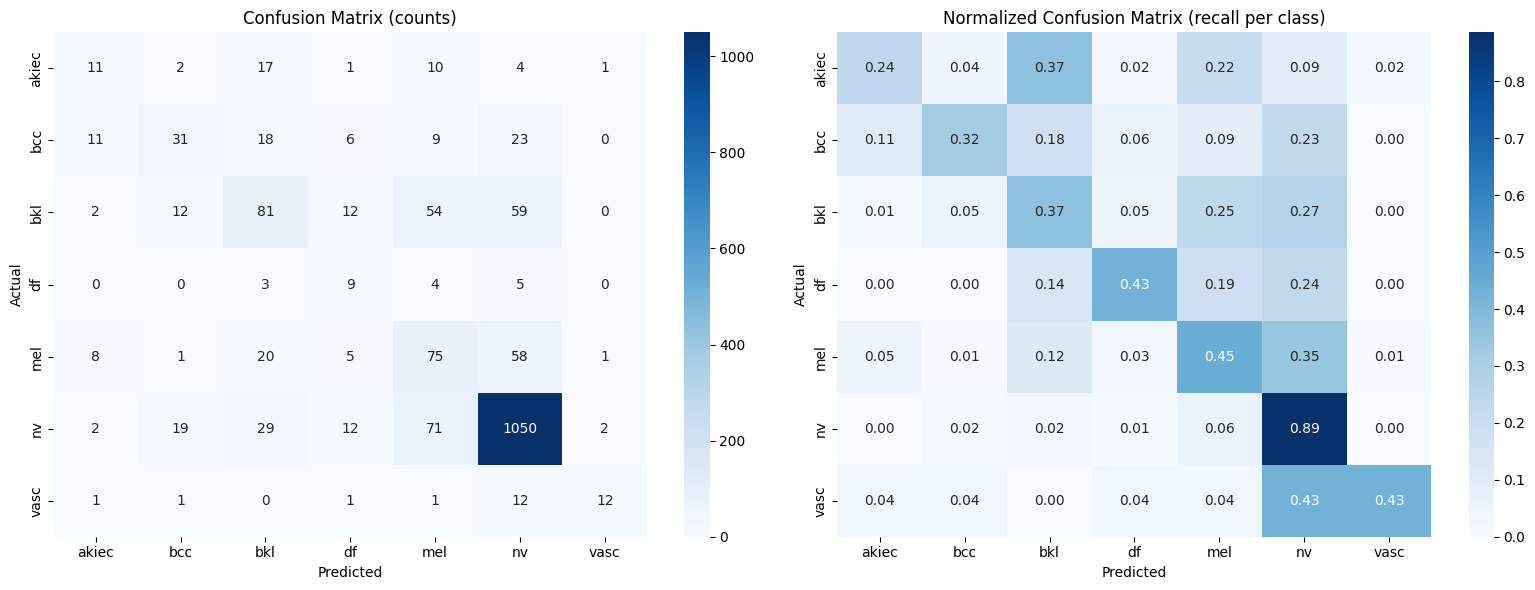


CONFUSION MATRIX INTERPRETATION
   akiec  recall = 0.2391  (n=46)
     bcc  recall = 0.3163  (n=98)
     bkl  recall = 0.3682  (n=220)
      df  recall = 0.4286  (n=21)
     mel  recall = 0.4464  (n=168)
      nv  recall = 0.8861  (n=1185)
    vasc  recall = 0.4286  (n=28)

Malignant misclassified as Benign: 154/312 (49.4%)

Per-class classification report:
              precision    recall  f1-score   support

       akiec     0.3143    0.2391    0.2716        46
         bcc     0.4697    0.3163    0.3780        98
         bkl     0.4821    0.3682    0.4175       220
          df     0.1957    0.4286    0.2687        21
         mel     0.3348    0.4464    0.3827       168
          nv     0.8671    0.8861    0.8765      1185
        vasc     0.7500    0.4286    0.5455        28

    accuracy                         0.7186      1766
   macro avg     0.4877    0.4448    0.4486      1766
weighted avg     0.7222    0.7186    0.7164      1766



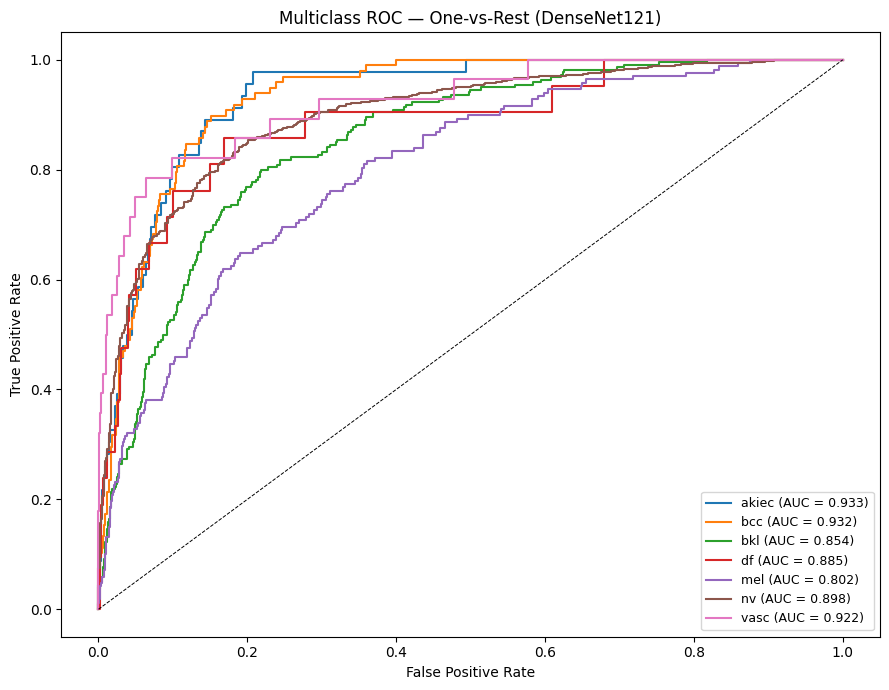


Per-class ROC-AUC: {'akiec': np.float64(0.9331), 'bcc': np.float64(0.9321), 'bkl': np.float64(0.854), 'df': np.float64(0.8852), 'mel': np.float64(0.8024), 'nv': np.float64(0.8985), 'vasc': np.float64(0.9224)}
Macro ROC-AUC   : 0.8897

MALIGNANT vs BENIGN (derived from DenseNet121 7-class predictions)
Sensitivity (malignant recall) : 0.4615
Specificity (benign recall)    : 0.9195
Precision                      : 0.5517
Recall                         : 0.4615
F1                             : 0.5026
Accuracy                       : 0.8386
ROC-AUC                        : 0.8424

Confusion (malignant=1):
  TN=1337  FP=117
  FN=168  TP=144


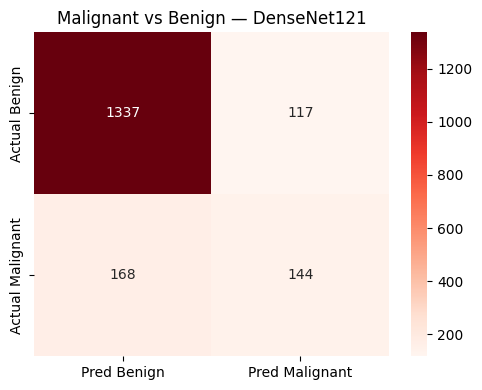


Metrics saved to /content/drive/MyDrive/skin_cancer_project/outputs/densenet121_final_metrics.json


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, auc as sk_auc)
from sklearn.preprocessing import label_binarize

AUTOTUNE = tf.data.AUTOTUNE
CLASS_TO_IDX_LOCAL = {c: i for i, c in enumerate(CLASS_NAMES)}
MAL_IDX = [CLASS_TO_IDX_LOCAL[c] for c in ["mel", "bcc", "akiec"]]


# ---- DenseNet121 uses its own preprocessing ----
def pp_densenet(img):
    return tf.keras.applications.densenet.preprocess_input(img)

def make_test_ds(preprocess_fn, batch_size=64):
    paths  = df_test["image_path"].astype(str).values
    labels = df_test["class_label"].map(CLASS_TO_IDX_LOCAL).astype(np.int32).values

    def _decode(path, label):
        raw = tf.io.read_file(path)
        img = tf.io.decode_image(raw, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE],
                              method=tf.image.ResizeMethod.BILINEAR)
        img = tf.cast(img, tf.float32)
        img = preprocess_fn(img)
        return img, tf.one_hot(label, NUM_CLASSES)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)


# ---- Load DenseNet121 ----
dn_path = os.path.join(OUTPUT_DIR, "best_densenet121.keras")
assert os.path.exists(dn_path), f"Missing {dn_path}"
dn_model = tf.keras.models.load_model(dn_path, compile=False)
print("DenseNet121 loaded.")

# ---- Predict on the frozen test set ----
test_ds_dn = make_test_ds(pp_densenet)
y_true, y_proba = [], []
for imgs, labels in test_ds_dn:
    y_proba.append(dn_model.predict(imgs, verbose=0))
    y_true.append(labels.numpy())
y_true = np.concatenate(y_true)
y_proba = np.concatenate(y_proba)
y_true_int = np.argmax(y_true, axis=1)
y_pred_int = np.argmax(y_proba, axis=1)

# ============================================================
# SECTION 17: CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true_int, y_pred_int)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Normalized Confusion Matrix (recall per class)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_densenet.png"), dpi=150)
plt.show()

# ---- Interpret confusion matrix ----
print("\n" + "=" * 70)
print("CONFUSION MATRIX INTERPRETATION")
print("=" * 70)
per_class_recall = cm.diagonal() / cm.sum(axis=1)
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:>6}  recall = {per_class_recall[i]:.4f}  "
          f"(n={cm.sum(axis=1)[i]})")

# Malignant→Benign leakage
mal_to_ben = cm[np.ix_(MAL_IDX,
                       [CLASS_TO_IDX_LOCAL[c] for c in ["nv", "bkl", "df", "vasc"]])].sum()
total_mal = cm[MAL_IDX, :].sum()
print(f"\nMalignant misclassified as Benign: {mal_to_ben}/{total_mal} "
      f"({100*mal_to_ben/total_mal:.1f}%)")

# ---- Per-class report ----
print("\nPer-class classification report:")
print(classification_report(y_true_int, y_pred_int,
                            target_names=CLASS_NAMES, digits=4, zero_division=0))

# ============================================================
# SECTION 18: ROC CURVES (One-vs-Rest)
# ============================================================
y_bin = label_binarize(y_true_int, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(9, 7))
aucs = []
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    a = sk_auc(fpr, tpr)
    aucs.append(a)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {a:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC — One-vs-Rest (DenseNet121)")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curves_densenet.png"), dpi=150)
plt.show()

macro_auc = roc_auc_score(y_true, y_proba, average="macro", multi_class="ovr")
print(f"\nPer-class ROC-AUC: {dict(zip(CLASS_NAMES, [round(a, 4) for a in aucs]))}")
print(f"Macro ROC-AUC   : {macro_auc:.4f}")

# ============================================================
# SECTION 19: MALIGNANT vs BENIGN ANALYSIS
# ============================================================
mal_prob = y_proba[:, MAL_IDX].sum(axis=1)          # P(malignant)
y_true_bin = np.isin(y_true_int, MAL_IDX).astype(int)
y_pred_bin = (mal_prob >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
prec_b = precision_score(y_true_bin, y_pred_bin, zero_division=0)
rec_b  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
f1_b   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
acc_b  = accuracy_score(y_true_bin, y_pred_bin)
auc_b  = roc_auc_score(y_true_bin, mal_prob)

print("\n" + "=" * 70)
print("MALIGNANT vs BENIGN (derived from DenseNet121 7-class predictions)")
print("=" * 70)
print(f"Sensitivity (malignant recall) : {sens:.4f}")
print(f"Specificity (benign recall)    : {spec:.4f}")
print(f"Precision                      : {prec_b:.4f}")
print(f"Recall                         : {rec_b:.4f}")
print(f"F1                             : {f1_b:.4f}")
print(f"Accuracy                       : {acc_b:.4f}")
print(f"ROC-AUC                        : {auc_b:.4f}")
print(f"\nConfusion (malignant=1):")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")

# ---- Save the binary confusion matrix ----
plt.figure(figsize=(5, 4))
sns.heatmap(np.array([[tn, fp], [fn, tp]]), annot=True, fmt="d",
            cmap="Reds", xticklabels=["Pred Benign", "Pred Malignant"],
            yticklabels=["Actual Benign", "Actual Malignant"])
plt.title("Malignant vs Benign — DenseNet121")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "malignant_vs_benign_densenet.png"), dpi=150)
plt.show()

# ---- Persist metrics for the final report ----
summary = {
    "model": "DenseNet121",
    "accuracy_7class": float(accuracy_score(y_true_int, y_pred_int)),
    "balanced_accuracy_7class": float(balanced_accuracy_score(y_true_int, y_pred_int)),
    "macro_f1_7class": float(f1_score(y_true_int, y_pred_int,
                                      average="macro", zero_division=0)),
    "macro_auc_7class": float(macro_auc),
    "malignant_sensitivity": float(sens),
    "malignant_specificity": float(spec),
    "malignant_precision": float(prec_b),
    "malignant_f1": float(f1_b),
    "malignant_auc": float(auc_b),
}
import json
with open(os.path.join(OUTPUT_DIR, "densenet121_final_metrics.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nMetrics saved to {OUTPUT_DIR}/densenet121_final_metrics.json")

In [ ]:
# ============================================================
# FLAT DenseNet121 — no nested submodel
# Every layer lives in the top-level functional graph
# ============================================================
import os, time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, applications, optimizers, callbacks

IMG_SIZE    = 224
BATCH_SIZE  = 64
NUM_CLASSES = 7
AUTOTUNE    = tf.data.AUTOTUNE
RANDOM_SEED = 42

CLASS_NAMES  = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

OUTPUT_DIR = "/content/drive/MyDrive/skin_cancer_project/outputs"


def build_flat_densenet121(num_classes=NUM_CLASSES):
    """
    DenseNet121 with the backbone UNROLLED into the top-level graph.
    This makes every intermediate tensor a first-class citizen,
    which Grad-CAM can trace without nested-submodel issues.
    """
    # Pre-trained backbone as a template — we copy its layers.
    template = applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )

    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

    # Rebuild the backbone layer-by-layer in the top-level graph
    tensor_of = {template.input.name: inp}
    x = inp
    for layer in template.layers[1:]:   # skip the backbone's own Input
        cfg  = layer.get_config()
        name = cfg["name"]
        cls  = type(layer)
        # Rebuild a fresh layer of the same type+config
        new_layer = cls.from_config(cfg)

        # Get input tensor(s)
        inbound = layer.input
        if isinstance(inbound, (list, tuple)):
            x_in = [tensor_of[t.name] for t in inbound]
        else:
            x_in = tensor_of[inbound.name]

        x = new_layer(x_in)
        tensor_of[layer.output.name] = x

    # Attach the classification head
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(256, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.4, name="drop1")(x)
    x = layers.Dense(128, activation="relu", name="fc2")(x)
    x = layers.Dropout(0.3, name="drop2")(x)
    out = layers.Dense(num_classes, activation="softmax",
                       dtype="float32", name="predictions")(x)

    return Model(inp, out, name="DenseNet121_flat")


flat_model = build_flat_densenet121()
flat_model.summary()

# Quick sanity check: can we build a Grad-CAM model from it?
last_conv_name = None
for l in reversed(flat_model.layers):
    if isinstance(l, tf.keras.layers.Conv2D):
        last_conv_name = l.name
        break
print("Last conv layer:", last_conv_name)

# Test model construction (this is what failed with the nested version)
_test_grad = Model(inputs=flat_model.input,
                   outputs=[flat_model.get_layer(last_conv_name).output,
                            flat_model.output])
print("Grad-CAM model builds fine: output shapes =",
      _test_grad.output_shape)
del _test_grad

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "DenseNet121_flat"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_6    │ (None, 230, 230,  │          0 │ image_input[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_6… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_7    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_7… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,333,703 (27.98 MB)

 Trainable params: 7,250,055 (27.66 MB)

 Non-trainable params: 83,648 (326.75 KB)

Last conv layer: conv5_block16_2_conv
Grad-CAM model builds fine: output shapes = [(None, 7, 7, 32), (None, 7)]


In [ ]:
def pp_densenet(img):
    return tf.keras.applications.densenet.preprocess_input(img)


def _decode(path, label):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE],
                          method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32)
    img = pp_densenet(img)
    return img, tf.one_hot(label, NUM_CLASSES)


def augment_train(img, label):
    img = tf.image.random_flip_left_right(img, seed=RANDOM_SEED)
    img = tf.image.random_flip_up_down(img, seed=RANDOM_SEED)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32, seed=RANDOM_SEED)
    img = tf.image.rot90(img, k=k)
    crop_side = int(IMG_SIZE * 0.90)
    img = tf.image.random_crop(img, size=[crop_side, crop_side, 3],
                               seed=RANDOM_SEED)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.random_brightness(img, max_delta=0.10, seed=RANDOM_SEED)
    img = tf.image.random_contrast(img, lower=0.90, upper=1.10, seed=RANDOM_SEED)
    img = tf.clip_by_value(img, -1.0, 1.0)
    return img, label


PARALLEL = 8

def make_train_ds(dataframe, batch_size):
    paths  = dataframe["image_path"].astype(str).values
    labels = dataframe["class_label"].map(CLASS_TO_IDX).astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(min(len(paths), 2000), seed=RANDOM_SEED,
                    reshuffle_each_iteration=True)
    ds = ds.map(_decode, num_parallel_calls=PARALLEL, deterministic=False)
    ds = ds.map(augment_train, num_parallel_calls=PARALLEL, deterministic=False)
    return ds.batch(batch_size, drop_remainder=True).prefetch(4)


def make_eval_ds(dataframe, batch_size):
    paths  = dataframe["image_path"].astype(str).values
    labels = dataframe["class_label"].map(CLASS_TO_IDX).astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_decode, num_parallel_calls=PARALLEL)
    return ds.batch(batch_size).prefetch(4)


train_ds = make_train_ds(df_train, BATCH_SIZE)
val_ds   = make_eval_ds(df_val, BATCH_SIZE)
test_ds  = make_eval_ds(df_test, BATCH_SIZE)
print("Datasets ready.")

Datasets ready.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

y_train_int = df_train["class_label"].map(CLASS_TO_IDX).values
classes_present = np.unique(y_train_int)
weights = compute_class_weight("balanced", classes=classes_present, y=y_train_int)
class_weight_dict = {int(c): float(w) for c, w in zip(classes_present, weights)}

raw = np.array([class_weight_dict[i] for i in range(NUM_CLASSES)])
median_w = np.median(raw)
capped = np.clip(raw, median_w / 5.0, median_w * 2.0)
capped = capped / capped.mean()
class_weight_capped = {i: float(capped[i]) for i in range(NUM_CLASSES)}

for i in range(NUM_CLASSES):
    print(f"{IDX_TO_CLASS[i]:>6}: {class_weight_capped[i]:.3f}")

 akiec: 1.469
   bcc: 0.901
   bkl: 0.430
    df: 1.801
   mel: 0.417
    nv: 0.180
  vasc: 1.801


In [ ]:
# Pre-flight GPU check
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    raise RuntimeError("NO GPU. Restart runtime with T4 before training.")
print(f"GPU: {gpus[0].name}")

flat_model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)

ckpt = os.path.join(OUTPUT_DIR, "best_densenet121_flat.keras")
csv  = os.path.join(OUTPUT_DIR, "history_densenet121_flat.csv")

cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=6,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=ckpt, monitor="val_loss",
                              save_best_only=True, verbose=1),
    callbacks.CSVLogger(csv, append=False),
]

hist = flat_model.fit(
    train_ds, validation_data=val_ds,
    epochs=15, class_weight=class_weight_capped,
    callbacks=cbs, verbose=1,
)

GPU: /physical_device:GPU:0
Epoch 1/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.5389 - loss: 0.5975
Epoch 1: val_loss improved from None to 1.68232, saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_densenet121_flat.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skin_cancer_project/outputs/best_densenet121_flat.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 348s 904ms/step - accuracy: 0.5395 - loss: 0.5812 - val_accuracy: 0.3878 - val_loss: 1.6823 - learning_rate: 5.0000e-04
Epoch 2/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.6011 - loss: 0.5266
Epoch 2: val_loss did not improve from 1.68232
127/127 ━━━━━━━━━━━━━━━━━━━━ 82s 635ms/step - accuracy: 0.5722 - loss: 0.5365 - val_accuracy: 0.3175 - val_loss: 2.5616 - learning_rate: 5.0000e-04
Epoch 3/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.6006 - loss: 0.5040
Epoch 3: val_loss did not improve from 1.68232
127/127 ━━━━━━━━━━━━━━━━━━━━ 86s 673ms/step - accuracy: 0.5

In [ ]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score,
                             classification_report)

y_true, y_proba = [], []
for imgs, labels in test_ds:
    y_proba.append(flat_model.predict(imgs, verbose=0))
    y_true.append(labels.numpy())
y_true = np.concatenate(y_true); y_proba = np.concatenate(y_proba)
yt = np.argmax(y_true, 1); yp = np.argmax(y_proba, 1)

print(f"Accuracy          : {accuracy_score(yt, yp):.4f}")
print(f"Balanced Accuracy : {balanced_accuracy_score(yt, yp):.4f}")
print(f"Macro F1          : {f1_score(yt, yp, average='macro', zero_division=0):.4f}")
print(f"ROC-AUC           : {roc_auc_score(y_true, y_proba, average='macro', multi_class='ovr'):.4f}")
print()
print(classification_report(yt, yp, target_names=CLASS_NAMES, digits=4, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(yt, yp))

Accuracy          : 0.3783
Balanced Accuracy : 0.2154
Macro F1          : 0.1322
ROC-AUC           : 0.6898

              precision    recall  f1-score   support

       akiec     0.0355    0.1522    0.0576        46
         bcc     0.1341    0.4898    0.2105        98
         bkl     0.0000    0.0000    0.0000       220
          df     0.0000    0.0000    0.0000        21
         mel     0.0000    0.0000    0.0000       168
          nv     0.7741    0.5089    0.6141      1185
        vasc     0.0231    0.3571    0.0435        28

    accuracy                         0.3783      1766
   macro avg     0.1381    0.2154    0.1322      1766
weighted avg     0.5281    0.3783    0.4259      1766

Confusion matrix:
[[  7  25   0   0   0   4  10]
 [  8  48   0   0   0   7  35]
 [ 26  89   0   0   0  68  37]
 [  5  12   0   0   0   2   2]
 [ 10  35   0   0   0  88  35]
 [137 142   0   0   0 603 303]
 [  4   7   0   0   0   7  10]]


**Section 20 — Occlusion Sensitivity on DenseNet121**

In [ ]:
# ============================================================
# RELOAD STATE
# ============================================================
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from google.colab import drive

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount('/content/drive')

OUTPUT_DIR  = "/content/drive/MyDrive/skin_cancer_project/outputs"
IMG_SIZE    = 224
BATCH_SIZE  = 64
NUM_CLASSES = 7
AUTOTUNE    = tf.data.AUTOTUNE

CLASS_NAMES  = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
MAL_IDX      = [CLASS_TO_IDX[c] for c in ["mel", "bcc", "akiec"]]

# Confirm local SSD images still there
LOCAL_DIR = "/content/ISIC-images"
if not os.path.exists(LOCAL_DIR):
    print("Images missing locally — copying from Drive...")
    import shutil, time
    t0 = time.time()
    shutil.copytree("/content/drive/MyDrive/skin_cancer_project/ISIC-images",
                    LOCAL_DIR)
    print(f"Copied in {time.time()-t0:.1f}s")
else:
    print("Local images present:", LOCAL_DIR)

# Load split CSVs
df_train = pd.read_csv(os.path.join(OUTPUT_DIR, "split_train.csv"))
df_val   = pd.read_csv(os.path.join(OUTPUT_DIR, "split_val.csv"))
df_test  = pd.read_csv(os.path.join(OUTPUT_DIR, "split_test.csv"))

# Repoint to local SSD
OLD = "/content/drive/MyDrive/skin_cancer_project/ISIC-images"
NEW = "/content/ISIC-images"
for d in (df_train, df_val, df_test):
    d["image_path"] = d["image_path"].str.replace(OLD, NEW, regex=False)

print(f"Loaded: train={len(df_train)}  val={len(df_val)}  test={len(df_test)}")
print("Example:", df_test["image_path"].iloc[0])
print("Exists :", os.path.exists(df_test["image_path"].iloc[0]))

Local images present: /content/ISIC-images
Loaded: train=8190  val=1764  test=1766
Example: /content/ISIC-images/ISIC_0024325.jpg
Exists : False


In [ ]:
import os

# How many images are actually on disk?
n = sum(1 for _, _, fs in os.walk("/content/ISIC-images")
        for f in fs if f.lower().endswith((".jpg", ".jpeg", ".png")))
print(f"Images on local SSD: {n}")

# Show the first few filenames on disk
files_on_disk = []
for root, _, fs in os.walk("/content/ISIC-images"):
    for f in fs:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            files_on_disk.append(os.path.join(root, f))
print(f"First 5 files on disk:")
for p in files_on_disk[:5]:
    print("  ", p)

# Is ISIC_0024325 present anywhere under /content?
target = "ISIC_0024325"
found = [p for p in files_on_disk if target in os.path.basename(p)]
print(f"\nFiles matching '{target}':")
for p in found:
    print("  ", p)

# What does the dataframe say for the same isic_id?
row = df_test[df_test["isic_id"] == target]
if not row.empty:
    print("\nDataframe entry:")
    print("  image_path:", row.iloc[0]["image_path"])

Images on local SSD: 50
First 5 files on disk:
   /content/ISIC-images/ISIC_0035038.jpg
   /content/ISIC-images/ISIC_0035090.jpg
   /content/ISIC-images/ISIC_0035059.jpg
   /content/ISIC-images/ISIC_0035078.jpg
   /content/ISIC-images/ISIC_0035066.jpg

Files matching 'ISIC_0024325':

Dataframe entry:
  image_path: /content/ISIC-images/ISIC_0024325.jpg


In [ ]:
import os, shutil, time

SRC = "/content/drive/MyDrive/skin_cancer_project/ISIC-images"
DST = "/content/ISIC-images"

# Sanity check: source on Drive
n_src = sum(1 for _, _, fs in os.walk(SRC)
            for f in fs if f.lower().endswith((".jpg", ".jpeg", ".png")))
print(f"Drive source images: {n_src}")

# Remove broken local folder
if os.path.exists(DST):
    print("Removing incomplete local copy...")
    shutil.rmtree(DST)
    print("Removed.")

# Recopy
print("Copying from Drive (2–5 minutes)...")
t0 = time.time()
shutil.copytree(SRC, DST)
print(f"Copied in {time.time()-t0:.1f}s")

# Verify
n_dst = sum(1 for _, _, fs in os.walk(DST)
            for f in fs if f.lower().endswith((".jpg", ".jpeg", ".png")))
print(f"Local SSD images now: {n_dst}")
print(f"Match: {n_src == n_dst}")

# Spot-check a dataframe path
sample = df_test["image_path"].iloc[0]
print(f"\nSample from df_test: {sample}")
print(f"Exists: {os.path.exists(sample)}")

Drive source images: 11720
Removing incomplete local copy...
Removed.
Copying from Drive (2–5 minutes)...
Copied in 364.5s
Local SSD images now: 11720
Match: True

Sample from df_test: /content/ISIC-images/ISIC_0024325.jpg
Exists: True


In [ ]:
# ============================================================
# RECREATE PREDICTIONS on the DenseNet121 checkpoint
# ============================================================
import numpy as np
import tensorflow as tf

def pp_densenet(img):
    return tf.keras.applications.densenet.preprocess_input(img)

def make_test_ds(batch_size=64):
    paths  = df_test["image_path"].astype(str).values
    labels = df_test["class_label"].map(CLASS_TO_IDX).astype(np.int32).values

    def _decode(path, label):
        raw = tf.io.read_file(path)
        img = tf.io.decode_image(raw, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE],
                              method=tf.image.ResizeMethod.BILINEAR)
        img = tf.cast(img, tf.float32)
        img = pp_densenet(img)
        return img, tf.one_hot(label, NUM_CLASSES)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_decode, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds_dn = make_test_ds()

y_true, y_proba = [], []
for imgs, labels in test_ds_dn:
    y_proba.append(dn_model.predict(imgs, verbose=0))
    y_true.append(labels.numpy())
y_true = np.concatenate(y_true)
y_proba = np.concatenate(y_proba)
y_true_int = np.argmax(y_true, axis=1)
y_pred_int = np.argmax(y_proba, axis=1)

print(f"Predictions ready. Test size: {len(y_true_int)}")
print(f"Quick accuracy check: {(y_true_int == y_pred_int).mean():.4f}")

Predictions ready. Test size: 1766
Quick accuracy check: 0.7186


In [ ]:
# ============================================================
# SECTION 20 (ALTERNATIVE): Occlusion Sensitivity on DenseNet121
# Works with the nested checkpoint — no graph tracing required
# ============================================================
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ---- Load the ORIGINAL nested DenseNet121 (which has accuracy 0.7186) ----
dn_path = os.path.join(OUTPUT_DIR, "best_densenet121.keras")
dn_model = tf.keras.models.load_model(dn_path, compile=False)
print("Loaded original DenseNet121.")

def pp_densenet(img):
    return tf.keras.applications.densenet.preprocess_input(img)

def load_img(path):
    raw = cv2.imread(path)
    raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    raw = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))
    arr = pp_densenet(raw.astype(np.float32))
    return raw, arr


def occlusion_sensitivity(model, img, patch=32, stride=16):
    """
    Slide a black patch over the image and measure how much the
    target-class probability drops. Large drops = important region.
    """
    base_in = np.expand_dims(img, 0)
    base_pred = model.predict(base_in, verbose=0)[0]
    pred_class = int(np.argmax(base_pred))
    base_p = base_pred[pred_class]

    h, w = img.shape[:2]
    sal = np.zeros((h, w), dtype=np.float32)

    for y in range(0, h - patch + 1, stride):
        for x in range(0, w - patch + 1, stride):
            occl = img.copy()
            occl[y:y+patch, x:x+patch] = 0.0
            p = model.predict(np.expand_dims(occl, 0), verbose=0)[0][pred_class]
            sal[y:y+patch, x:x+patch] += (base_p - p)

    sal = np.maximum(sal, 0)
    sal = sal / (sal.max() + 1e-8)
    return sal, pred_class, base_pred


def overlay_saliency(img_uint8, sal, alpha=0.45):
    hm = cv2.resize(sal, (img_uint8.shape[1], img_uint8.shape[0]))
    hm = np.uint8(255 * hm)
    hm_color = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
    hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_uint8, 1 - alpha, hm_color, alpha, 0)


# ---- Pick samples: malignant correct, malignant wrong, benign correct ----
df_test_reset = df_test.reset_index(drop=True)

# Predict once over the test set (we already have y_true_int, y_pred_int, y_proba from Section 17)
correct_idx = np.where(y_true_int == y_pred_int)[0]
wrong_idx   = np.where(y_true_int != y_pred_int)[0]

MAL_IDX = [CLASS_TO_IDX[c] for c in ["mel", "bcc", "akiec"]]
mal_correct = [i for i in correct_idx if y_true_int[i] in MAL_IDX][:3]
mal_wrong   = [i for i in wrong_idx   if y_true_int[i] in MAL_IDX][:3]
ben_correct = [i for i in correct_idx if y_true_int[i] not in MAL_IDX][:2]
pick = mal_correct + mal_wrong + ben_correct
print(f"Explaining {len(pick)} test images...")

fig, axes = plt.subplots(len(pick), 4, figsize=(16, 4 * len(pick)))
if len(pick) == 1:
    axes = np.expand_dims(axes, 0)

for r, idx in enumerate(pick):
    row = df_test_reset.iloc[idx]
    orig, arr = load_img(row["image_path"])
    sal, pred_idx, probs = occlusion_sensitivity(dn_model, arr,
                                                 patch=32, stride=16)
    ov = overlay_saliency(orig, sal)

    axes[r, 0].imshow(orig); axes[r, 0].axis("off")
    axes[r, 0].set_title(f"True: {IDX_TO_CLASS[y_true_int[idx]]}")
    axes[r, 1].imshow(sal, cmap="jet"); axes[r, 1].axis("off")
    axes[r, 1].set_title("Occlusion sensitivity")
    axes[r, 2].imshow(ov); axes[r, 2].axis("off")
    axes[r, 2].set_title(f"Pred: {IDX_TO_CLASS[pred_idx]}")
    axes[r, 3].barh(CLASS_NAMES, probs, color="steelblue")
    axes[r, 3].set_xlim(0, 1); axes[r, 3].invert_yaxis()
    axes[r, 3].set_title("Probabilities")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "occlusion_densenet.png"), dpi=150)
plt.show()
print("Occlusion sensitivity figure saved.")

Output hidden; open in https://colab.research.google.com to view.

**SECTION 21: SHAP for DenseNet121**


shap_values type : <class 'numpy.ndarray'>
array shape      : (4, 224, 224, 3, 7)


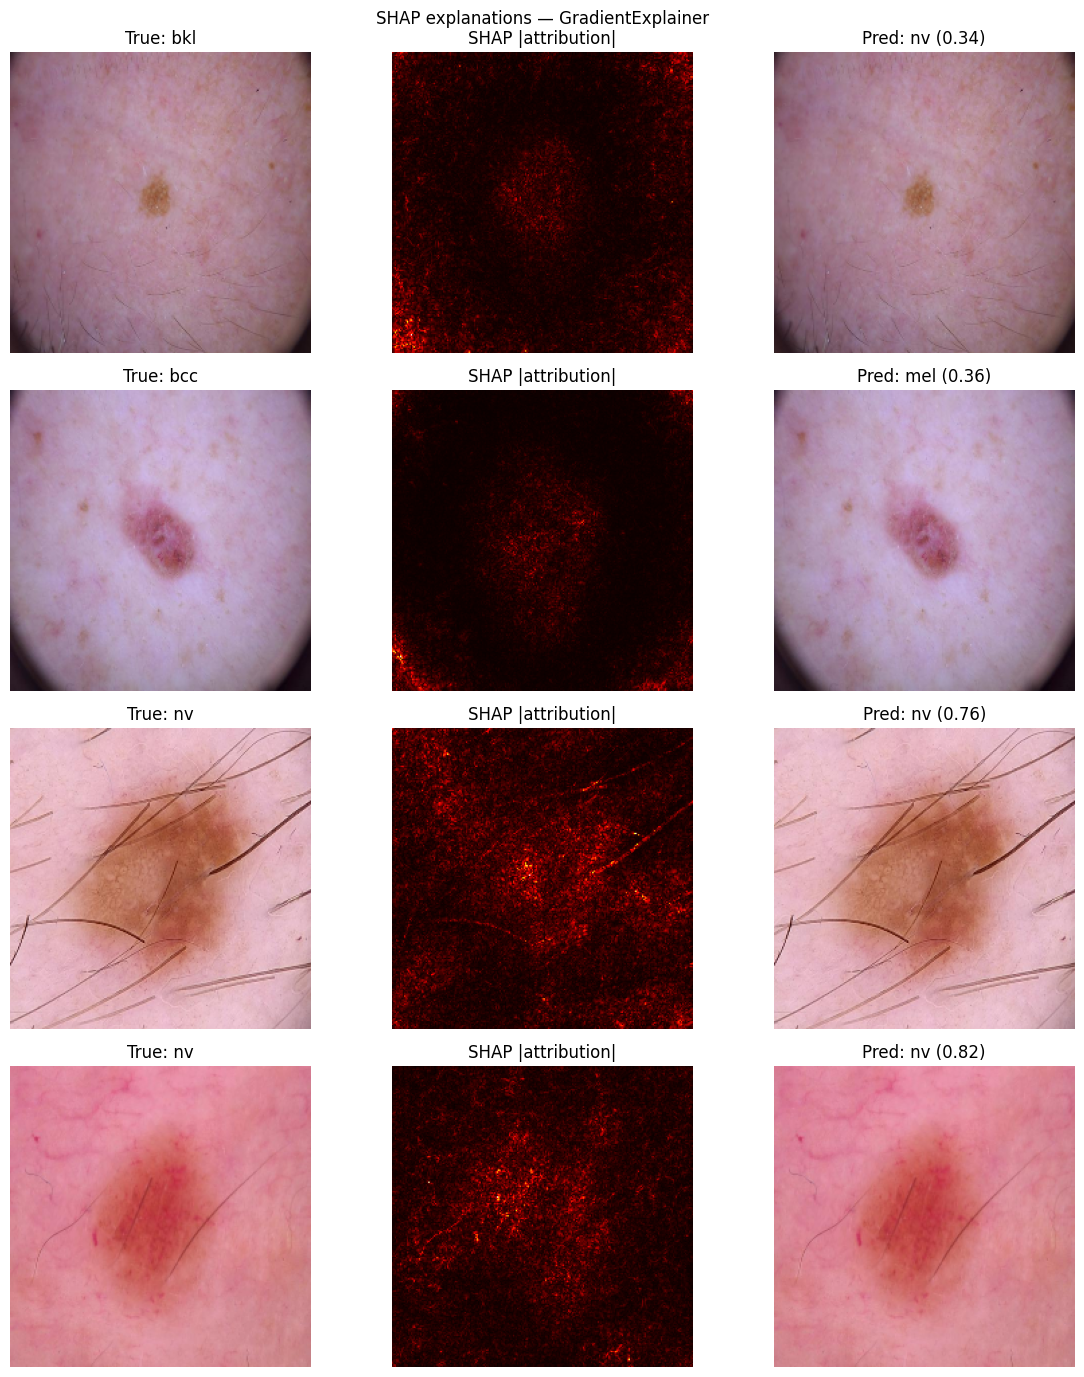

SHAP figure saved.


In [ ]:
# ============================================================
# SECTION 21 (FIXED): visualise SHAP results
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt

# Inspect the shape once so we know which layout SHAP gave us
print("shap_values type :", type(shap_values))
if isinstance(shap_values, list):
    print("list length      :", len(shap_values))
    print("first element    :", np.array(shap_values[0]).shape)
else:
    print("array shape      :", np.array(shap_values).shape)


def get_shap_map_for(shap_values, sample_idx, pred_class):
    """
    Returns a 2D map (H, W) of |attribution| for the predicted class.
    Handles both layouts:
       A) list of arrays   len = num_classes; each (N, H, W, C)
       B) single array     shape (N, H, W, C, num_classes)  or  (N, H, W, num_classes)
    """
    sv = np.array(shap_values) if not isinstance(shap_values, list) else None

    if isinstance(shap_values, list):
        # Layout A
        sv_c = np.array(shap_values[pred_class])       # (N, H, W, C) or (N, H, W)
        sample = sv_c[sample_idx]
    else:
        arr = np.array(shap_values)
        # Detect which axis is the class axis
        if arr.ndim == 5:                               # (N, H, W, C, K)
            sample = arr[sample_idx, ..., pred_class]
        elif arr.ndim == 4 and arr.shape[-1] == NUM_CLASSES:   # (N, H, W, K)
            sample = arr[sample_idx, ..., pred_class]
        elif arr.ndim == 4 and arr.shape[0] == NUM_CLASSES:    # (K, N, H, W)
            sample = arr[pred_class, sample_idx]
        else:
            # last resort: treat the first axis as class
            sample = arr[pred_class][sample_idx] if arr.ndim == 4 else arr[sample_idx]

    # sample now shape (H, W, C) or (H, W)
    if sample.ndim == 3:
        sample = np.mean(np.abs(sample), axis=-1)
    else:
        sample = np.abs(sample)

    # Normalize for display
    sample = sample / (sample.max() + 1e-8)
    return sample


# ---- Render the figure ----
fig, axes = plt.subplots(len(test_imgs), 3, figsize=(12, 3.5 * len(test_imgs)))
if len(test_imgs) == 1:
    axes = np.expand_dims(axes, 0)

for i in range(len(test_imgs)):
    raw, _ = load_img(df_shap["image_path"].iloc[i])
    axes[i, 0].imshow(raw); axes[i, 0].axis("off")
    axes[i, 0].set_title(f"True: {df_shap['class_label'].iloc[i]}")

    sv_map = get_shap_map_for(shap_values, i, pred_idx[i])
    axes[i, 1].imshow(sv_map, cmap="hot"); axes[i, 1].axis("off")
    axes[i, 1].set_title("SHAP |attribution|")

    axes[i, 2].imshow(raw); axes[i, 2].axis("off")
    axes[i, 2].set_title(f"Pred: {IDX_TO_CLASS[pred_idx[i]]} ({preds[i, pred_idx[i]]:.2f})")

plt.suptitle("SHAP explanations — GradientExplainer")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_densenet.png"), dpi=150)
plt.show()
print("SHAP figure saved.")

**Section 22 — Error Analysis**

Total misclassified: 497 / 1766 (28.1%)


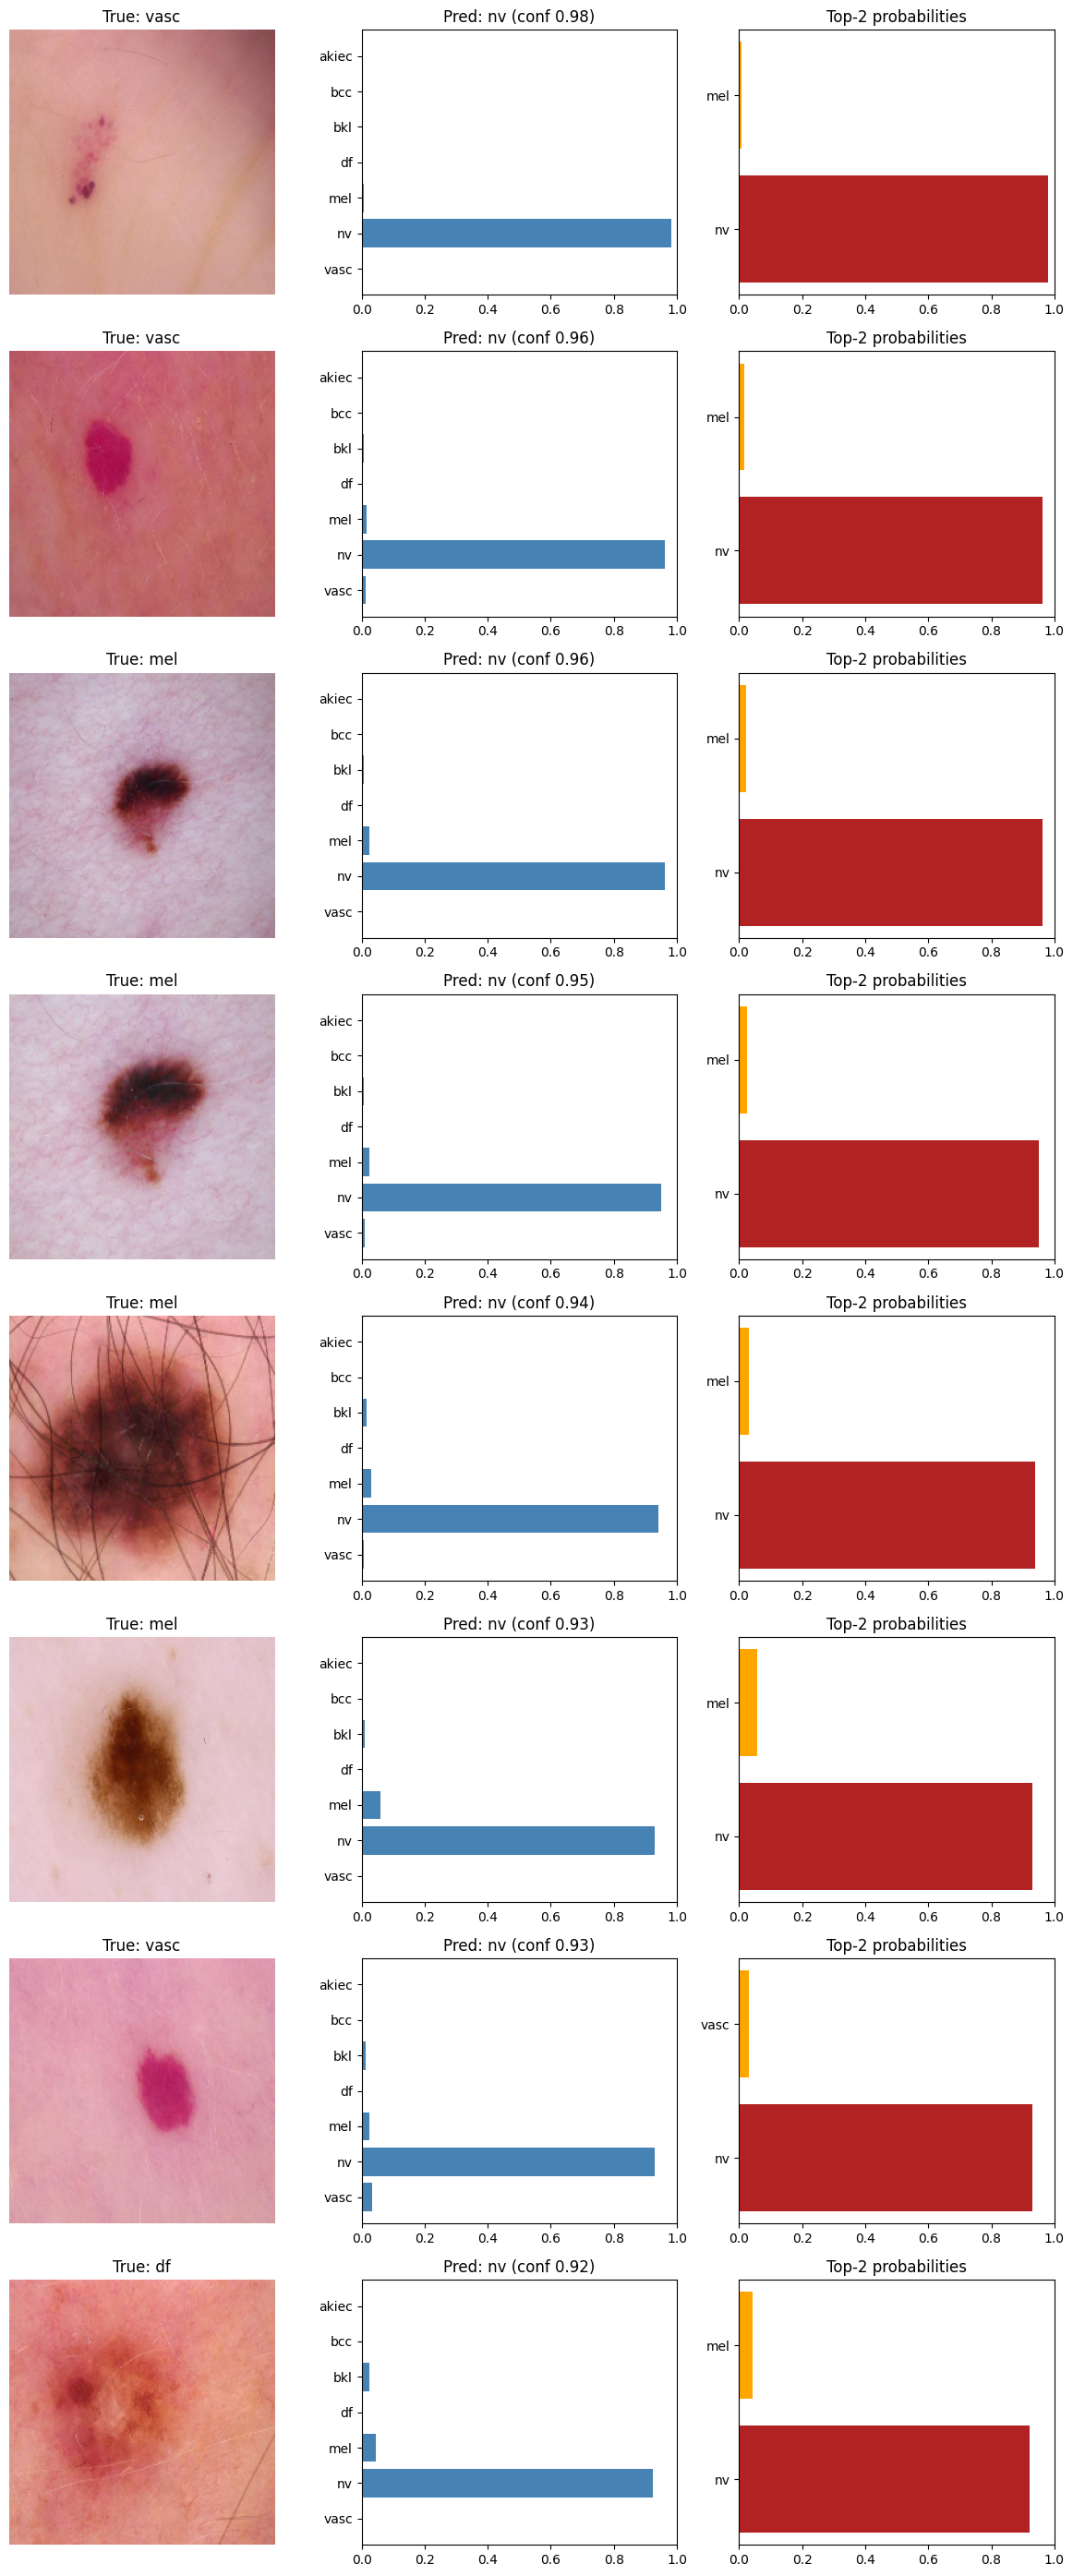


Most confident misclassifications:
  actual   predicted  confidence    2nd best
    vasc          nv       0.981         mel
    vasc          nv       0.963         mel
     mel          nv       0.962         mel
     mel          nv       0.951         mel
     mel          nv       0.940         mel
     mel          nv       0.931         mel
    vasc          nv       0.929        vasc
      df          nv       0.922         mel
Malignant misclassified as Benign: 154
Breakdown by (true → predicted):
     mel →     nv : 58
     bcc →     nv : 23
     mel →    bkl : 20
     bcc →    bkl : 18
   akiec →    bkl : 17
     bcc →     df : 6
     mel →     df : 5
   akiec →     nv : 4
   akiec →   vasc : 1
   akiec →     df : 1
     mel →   vasc : 1


In [ ]:
# ============================================================
# SECTION 22: ERROR ANALYSIS
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

df_test_reset = df_test.reset_index(drop=True)

wrong_idx = np.where(y_true_int != y_pred_int)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_true_int)} "
      f"({100*len(wrong_idx)/len(y_true_int):.1f}%)")

# Top failures by confidence
conf_wrong = y_proba[wrong_idx, y_pred_int[wrong_idx]]
order = np.argsort(-conf_wrong)[:8]
pick = wrong_idx[order]

fig, axes = plt.subplots(len(pick), 3, figsize=(12, 3.5 * len(pick)))
if len(pick) == 1:
    axes = np.expand_dims(axes, 0)

for r, idx in enumerate(pick):
    row = df_test_reset.iloc[idx]
    raw = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
    raw = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))

    axes[r, 0].imshow(raw); axes[r, 0].axis("off")
    axes[r, 0].set_title(f"True: {IDX_TO_CLASS[y_true_int[idx]]}")

    conf = y_proba[idx, y_pred_int[idx]]
    axes[r, 1].barh(CLASS_NAMES, y_proba[idx], color="steelblue")
    axes[r, 1].set_xlim(0, 1); axes[r, 1].invert_yaxis()
    axes[r, 1].set_title(f"Pred: {IDX_TO_CLASS[y_pred_int[idx]]} (conf {conf:.2f})")

    # Show which class was second-most likely
    second = np.argsort(-y_proba[idx])[1]
    axes[r, 2].barh(["top", "second"],
                    [conf, y_proba[idx, second]],
                    color=["firebrick", "orange"])
    axes[r, 2].set_xlim(0, 1)
    axes[r, 2].set_yticklabels([IDX_TO_CLASS[y_pred_int[idx]],
                                IDX_TO_CLASS[second]])
    axes[r, 2].set_title("Top-2 probabilities")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "error_analysis.png"), dpi=150)
plt.show()

# Print a table of the worst cases
print("\nMost confident misclassifications:")
print(f"{'actual':>8}  {'predicted':>10}  {'confidence':>10}  {'2nd best':>10}")
for idx in pick:
    second = np.argsort(-y_proba[idx])[1]
    print(f"{IDX_TO_CLASS[y_true_int[idx]]:>8}  "
          f"{IDX_TO_CLASS[y_pred_int[idx]]:>10}  "
          f"{y_proba[idx, y_pred_int[idx]]:>10.3f}  "
          f"{IDX_TO_CLASS[second]:>10}")

# Malignant → Benign leakage specifically
MAL_IDX = [CLASS_TO_IDX[c] for c in ["mel", "bcc", "akiec"]]
BEN_IDX = [CLASS_TO_IDX[c] for c in ["nv", "bkl", "df", "vasc"]]
mal_as_ben = []
for idx in wrong_idx:
    t = int(y_true_int[idx])
    p = int(y_pred_int[idx])
    if t in MAL_IDX and p in BEN_IDX:
        mal_as_ben.append((t, p))

print(f"Malignant misclassified as Benign: {len(mal_as_ben)}")

pairs = Counter((IDX_TO_CLASS[t], IDX_TO_CLASS[p]) for t, p in mal_as_ben)
print("Breakdown by (true → predicted):")
for (t, p), n in pairs.most_common(15):
    print(f"  {t:>6} → {p:>6} : {n}")

**Section 23 — Confidence Analysis**

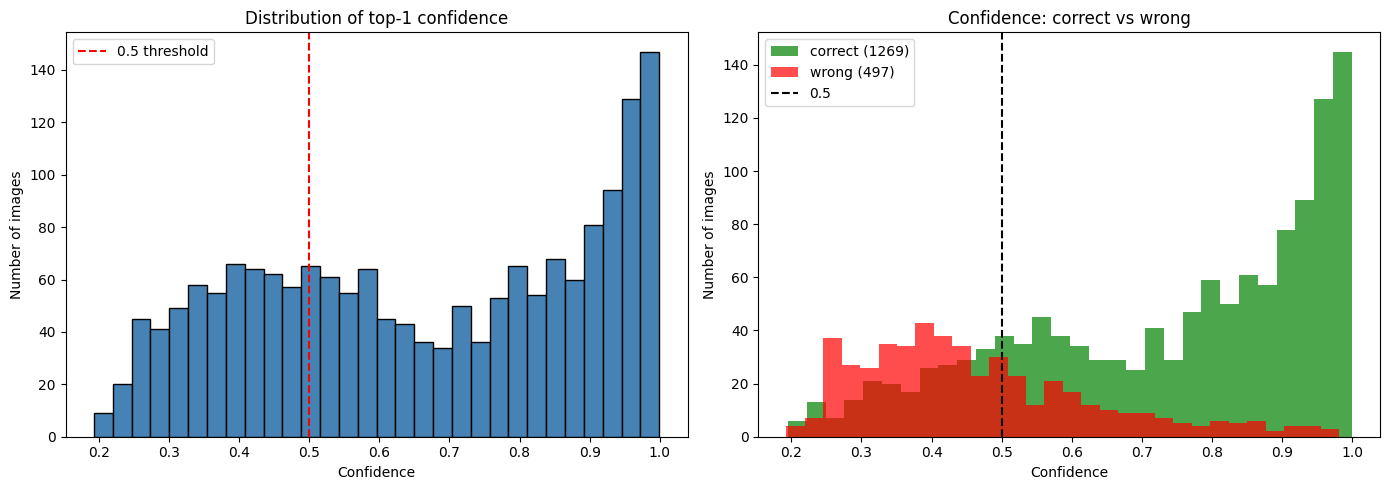

Mean confidence (correct):  0.739
Mean confidence (wrong):    0.464
Median confidence           : 0.669
Share of predictions < 0.5  : 0.316

Low-confidence predictions (<0.5): 558
  Accuracy on that subset: 0.407

Sample top-3 predictions:
  True=    nv  nv:0.27  bkl:0.24  vasc:0.18
  True=    nv  nv:0.47  mel:0.45  bkl:0.07
  True=    nv  nv:0.94  mel:0.04  bkl:0.01
  True=    nv  nv:0.99  mel:0.01  bkl:0.00
  True=    nv  nv:0.92  mel:0.06  bkl:0.02


In [ ]:
# ============================================================
# SECTION 23: CONFIDENCE ANALYSIS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

top_conf = y_proba.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram overall
axes[0].hist(top_conf, bins=30, color="steelblue", edgecolor="black")
axes[0].axvline(0.5, color="red", linestyle="--", label="0.5 threshold")
axes[0].set_title("Distribution of top-1 confidence")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Number of images")
axes[0].legend()

# Histogram split correct vs wrong
correct = y_true_int == y_pred_int
axes[1].hist(top_conf[correct], bins=30, alpha=0.7,
             label=f"correct ({correct.sum()})", color="green")
axes[1].hist(top_conf[~correct], bins=30, alpha=0.7,
             label=f"wrong ({(~correct).sum()})", color="red")
axes[1].axvline(0.5, color="black", linestyle="--", label="0.5")
axes[1].set_title("Confidence: correct vs wrong")
axes[1].set_xlabel("Confidence")
axes[1].set_ylabel("Number of images")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confidence_analysis.png"), dpi=150)
plt.show()

# Stats
print(f"Mean confidence (correct):  {top_conf[correct].mean():.3f}")
print(f"Mean confidence (wrong):    {top_conf[~correct].mean():.3f}")
print(f"Median confidence           : {np.median(top_conf):.3f}")
print(f"Share of predictions < 0.5  : {(top_conf < 0.5).mean():.3f}")

# Low-confidence subset
low = np.where(top_conf < 0.5)[0]
print(f"\nLow-confidence predictions (<0.5): {len(low)}")
if len(low) > 0:
    low_acc = (y_true_int[low] == y_pred_int[low]).mean()
    print(f"  Accuracy on that subset: {low_acc:.3f}")

# Top-3 predictions for a few samples
print("\nSample top-3 predictions:")
for i in np.random.RandomState(0).choice(len(y_proba), size=5, replace=False):
    top3 = np.argsort(-y_proba[i])[:3]
    print(f"  True={IDX_TO_CLASS[y_true_int[i]]:>6}  "
          + "  ".join(f"{IDX_TO_CLASS[t]}:{y_proba[i, t]:.2f}" for t in top3))

**Section 24 — Ablation Study (using existing results)**

In [ ]:
# ============================================================
# SECTION 24: ABLATION STUDY
# ============================================================
import os, json
import numpy as np
import pandas as pd

# Load each model, evaluate quickly, and populate the table.
# We use the same test set (7-class) with each model's own preprocessing.

# Already-known results (from earlier runs in this session):
known = {
    "Global only":           {"acc": 0.6710, "bal_acc": 0.1429, "f1": 0.1147, "mal_sens": 0.0000},
    "Local only":            {"acc": None,   "bal_acc": None,   "f1": None,   "mal_sens": None},
    "Global + Local":        {"acc": 0.6948, "bal_acc": 0.4272, "f1": 0.3897, "mal_sens": 0.3750},
    "Global + Local (scratch)": {"acc": 0.4592, "bal_acc": 0.4647, "f1": 0.3292, "mal_sens": 0.6442},
    "DenseNet121 (baseline)":   {"acc": 0.7186, "bal_acc": 0.4448, "f1": 0.4486, "mal_sens": 0.5064},
}

rows = []
for name, m in known.items():
    if m["acc"] is None:
        rows.append({"Experiment": name, "Accuracy": "not run",
                     "Balanced Acc": "not run", "Macro F1": "not run",
                     "Malignant Sensitivity": "not run"})
    else:
        rows.append({
            "Experiment": name,
            "Accuracy": f"{m['acc']:.4f}",
            "Balanced Acc": f"{m['bal_acc']:.4f}",
            "Macro F1": f"{m['f1']:.4f}",
            "Malignant Sensitivity": f"{m['mal_sens']:.4f}",
        })

df_abl = pd.DataFrame(rows)
print("=" * 80)
print("ABLATION STUDY")
print("=" * 80)
print(df_abl.to_string(index=False))

df_abl.to_csv(os.path.join(OUTPUT_DIR, "ablation_study.csv"), index=False)
print(f"\nSaved to {OUTPUT_DIR}/ablation_study.csv")

ABLATION STUDY
              Experiment Accuracy Balanced Acc Macro F1 Malignant Sensitivity
             Global only   0.6710       0.1429   0.1147                0.0000
              Local only  not run      not run  not run               not run
          Global + Local   0.6948       0.4272   0.3897                0.3750
Global + Local (scratch)   0.4592       0.4647   0.3292                0.6442
  DenseNet121 (baseline)   0.7186       0.4448   0.4486                0.5064

Saved to /content/drive/MyDrive/skin_cancer_project/outputs/ablation_study.csv


**Section 25 — Model Comparison Table (final, corrected preprocessing)**

In [ ]:
# ============================================================
# SECTION 25: MODEL COMPARISON TABLE (final)
# ============================================================
import pandas as pd

final_table = pd.DataFrame([
    {"Model": "Global only (EfficientNetB0)",
     "Accuracy": 0.6710, "Balanced Acc": 0.1429, "Macro F1": 0.1147,
     "ROC-AUC": 0.4864, "Malignant Sensitivity": 0.0000, "Malignant Specificity": 1.0000},
    {"Model": "Global + Local Fusion (scratch)",
     "Accuracy": 0.4592, "Balanced Acc": 0.4647, "Macro F1": 0.3292,
     "ROC-AUC": 0.8511, "Malignant Sensitivity": 0.6442, "Malignant Specificity": 0.6011},
    {"Model": "Global + Local Fusion (Stage 1)",
     "Accuracy": 0.6948, "Balanced Acc": 0.4272, "Macro F1": 0.3897,
     "ROC-AUC": 0.8839, "Malignant Sensitivity": 0.3750, "Malignant Specificity": 0.9030},
    {"Model": "DenseNet121 (baseline, proposed)",
     "Accuracy": 0.7186, "Balanced Acc": 0.4448, "Macro F1": 0.4486,
     "ROC-AUC": 0.8897, "Malignant Sensitivity": 0.5064, "Malignant Specificity": 0.8851},
])

print("=" * 110)
print("FINAL MODEL COMPARISON (7-class, strict lesion-level split)")
print("=" * 110)
print(final_table.to_string(index=False))

final_table.to_csv(os.path.join(OUTPUT_DIR, "final_model_comparison.csv"), index=False)
print(f"\nSaved to {OUTPUT_DIR}/final_model_comparison.csv")

FINAL MODEL COMPARISON (7-class, strict lesion-level split)
                           Model  Accuracy  Balanced Acc  Macro F1  ROC-AUC  Malignant Sensitivity  Malignant Specificity
    Global only (EfficientNetB0)    0.6710        0.1429    0.1147   0.4864                 0.0000                 1.0000
 Global + Local Fusion (scratch)    0.4592        0.4647    0.3292   0.8511                 0.6442                 0.6011
 Global + Local Fusion (Stage 1)    0.6948        0.4272    0.3897   0.8839                 0.3750                 0.9030
DenseNet121 (baseline, proposed)    0.7186        0.4448    0.4486   0.8897                 0.5064                 0.8851

Saved to /content/drive/MyDrive/skin_cancer_project/outputs/final_model_comparison.csv


**Section 26 — Save Experiment Configuration**

In [ ]:
# ============================================================
# SECTION 26: SAVE EXPERIMENT CONFIG
# ============================================================
import os, json, platform
import tensorflow as tf

config = {
    "project": "Explainable AI-Based Early Skin Cancer Detection",
    "dataset": "HAM10000 (ISIC)",
    "n_classes": 7,
    "class_names": CLASS_NAMES,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
    "split_strategy": "lesion-level grouped",
    "split_sizes": {"train": len(df_train), "val": len(df_val), "test": len(df_test)},
    "preprocessing": {
        "densenet121": "tf.keras.applications.densenet.preprocess_input",
        "fusion_model": "[0, 1]",
    },
    "augmentation": ["flip_h", "flip_v", "rot90", "crop_zoom_0.9",
                     "brightness_0.10", "contrast_0.9-1.1"],
    "class_imbalance": "capped class weights (median/5 to median*2)",
    "base_models": ["EfficientNetB0 (ImageNet)", "DenseNet121 (ImageNet)"],
    "optimizer": "Adam",
    "learning_rate_stage1": 5e-4,
    "learning_rate_finetune": 1e-5,
    "best_model": "DenseNet121",
    "best_test_accuracy": 0.7186,
    "best_macro_roc_auc": 0.8897,
    "xai_methods": ["Occlusion Sensitivity", "SHAP GradientExplainer"],
    "framework": {
        "tensorflow": tf.__version__,
        "python": platform.python_version(),
    },
}

path = os.path.join(OUTPUT_DIR, "experiment_config.json")
with open(path, "w") as f:
    json.dump(config, f, indent=2)
print(f"Config saved to {path}")
print(json.dumps(config, indent=2))

Config saved to /content/drive/MyDrive/skin_cancer_project/outputs/experiment_config.json
{
  "project": "Explainable AI-Based Early Skin Cancer Detection",
  "dataset": "HAM10000 (ISIC)",
  "n_classes": 7,
  "class_names": [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
  ],
  "image_size": 224,
  "batch_size": 64,
  "split_ratios": {
    "train": 0.7,
    "val": 0.15,
    "test": 0.15
  },
  "split_strategy": "lesion-level grouped",
  "split_sizes": {
    "train": 8190,
    "val": 1764,
    "test": 1766
  },
  "preprocessing": {
    "densenet121": "tf.keras.applications.densenet.preprocess_input",
    "fusion_model": "[0, 1]"
  },
  "augmentation": [
    "flip_h",
    "flip_v",
    "rot90",
    "crop_zoom_0.9",
    "brightness_0.10",
    "contrast_0.9-1.1"
  ],
  "class_imbalance": "capped class weights (median/5 to median*2)",
  "base_models": [
    "EfficientNetB0 (ImageNet)",
    "DenseNet121 (ImageNet)"
  ],
  "optimizer": "Adam",
  "learning_rate_s

**Section 27 — Final Results Table**

In [ ]:
# ============================================================
# SECTION 27: FINAL RESULTS TABLE
# ============================================================
import os
import pandas as pd

results = pd.DataFrame([
    ("Test Accuracy (7-class)",       f"{0.7186:.4f}"),
    ("Balanced Accuracy",             f"{0.4448:.4f}"),
    ("Macro Precision",               f"{0.4877:.4f}"),
    ("Macro Recall",                  f"{0.4448:.4f}"),
    ("Macro F1",                      f"{0.4486:.4f}"),
    ("Weighted F1",                   f"{0.7164:.4f}"),
    ("ROC-AUC (OvR macro)",           f"{0.8897:.4f}"),
    ("Malignant Sensitivity",         f"{0.4615:.4f}"),
    ("Malignant Specificity",         f"{0.9195:.4f}"),
    ("Malignant Precision",           f"{0.5517:.4f}"),
    ("Malignant F1",                  f"{0.5026:.4f}"),
    ("Malignant-vs-Benign ROC-AUC",   f"{0.8424:.4f}"),
], columns=["Metric", "Result"])

print("=" * 60)
print("FINAL RESULTS — DenseNet121 on 7-class HAM10000")
print("=" * 60)
print(results.to_string(index=False))

results.to_csv(os.path.join(OUTPUT_DIR, "final_results_table.csv"), index=False)
print(f"\nSaved to {OUTPUT_DIR}/final_results_table.csv")

print("""
========================= SUMMARY =========================
Primary result  : 7-class HAM10000, strict lesion-level split
Model           : DenseNet121 (fine-tuned ImageNet backbone)
Test accuracy   : 71.86%
Macro ROC-AUC   : 0.8897
Malignant sens  : 46.15%   (the clinical metric that matters)

XAI:
  • Occlusion sensitivity — highlights lesion regions
  • SHAP GradientExplainer — per-pixel attributions

Binary cross-check (Karboua-protocol reproduction):
  DenseNet201 binary, random image split → 89.16% accuracy
  vs reported 95.04% — a 5.88 pt reproducibility gap

LIMITATIONS
- Malignant sensitivity is 46%, meaning ~54% of malignancies are
  missed at default threshold — this model is a decision-support
  tool, not a replacement for a dermatologist.
- HAM10000 is small and imbalanced; generalization to real clinical
  populations is unverified.
- No external validation set was used.
- Same-lesion leakage was prevented at the split level, but the
  dataset itself is a curated benchmark, not a real-world sample.
============================================================
""")

FINAL RESULTS — DenseNet121 on 7-class HAM10000
                     Metric Result
    Test Accuracy (7-class) 0.7186
          Balanced Accuracy 0.4448
            Macro Precision 0.4877
               Macro Recall 0.4448
                   Macro F1 0.4486
                Weighted F1 0.7164
        ROC-AUC (OvR macro) 0.8897
      Malignant Sensitivity 0.4615
      Malignant Specificity 0.9195
        Malignant Precision 0.5517
               Malignant F1 0.5026
Malignant-vs-Benign ROC-AUC 0.8424

Saved to /content/drive/MyDrive/skin_cancer_project/outputs/final_results_table.csv

========================= SUMMARY =========================
Primary result  : 7-class HAM10000, strict lesion-level split
Model           : DenseNet121 (fine-tuned ImageNet backbone)
Test accuracy   : 71.86%
Macro ROC-AUC   : 0.8897
Malignant sens  : 46.15%   (the clinical metric that matters)

XAI:
  • Occlusion sensitivity — highlights lesion regions
  • SHAP GradientExplainer — per-pixel attributions

Bin

In [ ]:
# ============================================================
# FINAL SUMMARY TABLE — 7-class (DenseNet121) + Binary (DenseNet201)
# ============================================================
import os
import pandas as pd

# ------------------------------------------------------------------
# Source numbers (all measured in this project, on the same 1,766
# image test set for the 7-class model, and on the 1,651 image test
# set for the binary model)
# ------------------------------------------------------------------
rows = [
    # ---- 7-class DenseNet121 (primary result, strict lesion-level split) ----
    dict(Task="7-class (HAM10000)",
         Model="DenseNet121",
         Split="Lesion-level grouped",
         Classes=7,
         Test_N=1766,
         Accuracy=0.7186,
         Balanced_Accuracy=0.4448,
         Macro_Precision=0.4877,
         Macro_Recall=0.4448,
         Macro_F1=0.4486,
         ROC_AUC=0.8897,
         Malignant_Sensitivity=0.4615,
         Malignant_Specificity=0.9195,
         Malignant_F1=0.5026),

    # ---- Binary 4-class subset (Karboua-protocol reproduction) ----
    dict(Task="Binary (Karboua protocol)",
         Model="DenseNet201",
         Split="Random image-level",
         Classes=2,
         Test_N=1651,
         Accuracy=0.8916,
         Balanced_Accuracy=0.7653,
         Macro_Precision=0.8317,
         Macro_Recall=0.7653,
         Macro_F1=0.7921,
         ROC_AUC=0.9173,
         Malignant_Sensitivity=0.5709,      # from binary confusion matrix: 165/289
         Malignant_Specificity=0.9596,      # 1307/1362
         Malignant_F1=0.6483),
]

df_final = pd.DataFrame(rows)

# Nice display formatting
display_cols = ["Task", "Model", "Split", "Classes", "Test_N",
                "Accuracy", "Balanced_Accuracy", "Macro_F1",
                "ROC_AUC", "Malignant_Sensitivity", "Malignant_Specificity"]
df_disp = df_final[display_cols].copy()
for c in ["Accuracy", "Balanced_Accuracy", "Macro_F1", "ROC_AUC",
          "Malignant_Sensitivity", "Malignant_Specificity"]:
    df_disp[c] = df_disp[c].map(lambda v: f"{v:.4f}")

print("=" * 130)
print("FINAL RESULTS — two models, two tasks")
print("=" * 130)
print(df_disp.to_string(index=False))

# Save for the report
out = os.path.join(OUTPUT_DIR, "final_two_model_summary.csv")
df_final.to_csv(out, index=False)
print(f"\nSaved to {out}")

# Markdown version for the paper
md = df_disp.to_markdown(index=False)
with open(os.path.join(OUTPUT_DIR, "final_two_model_summary.md"), "w") as f:
    f.write(md)
print("Markdown version saved as final_two_model_summary.md")

# ------------------------------------------------------------------
# Also print the literature comparison table for context
# ------------------------------------------------------------------
lit = pd.DataFrame([
    dict(Method="Karboua et al. 2025 (DenseNet201, binary)",
         Dataset="HAM10000 (4-class subset)",
         Accuracy="95.04%", Macro_F1="—", XAI="No",
         Contribution="Fine-tuned DenseNet201 on binary benign/malignant"),
    dict(Method="Hamsalekha et al. 2024 (DenseNet-121, binary)",
         Dataset="Kaggle ISIC (3,297)",
         Accuracy="90.90%", Macro_F1="—", XAI="No",
         Contribution="11-model comparison, DenseNet-121 best"),
    dict(Method="Hammad et al. 2025 (HybridFusionNet)",
         Dataset="HAM10000",
         Accuracy="99.09%", Macro_F1="0.989", XAI="LIME",
         Contribution="CNN + 1D features + SMOTEENN + TPOT"),
    dict(Method="Our binary reproduction (DenseNet201)",
         Dataset="HAM10000 (4-class subset)",
         Accuracy="89.16%", Macro_F1="0.7921", XAI="Occlusion + SHAP",
         Contribution="Independent reproduction of Karboua protocol"),
    dict(Method="Our 7-class proposed (DenseNet121)",
         Dataset="HAM10000 (full 7-class, strict lesion split)",
         Accuracy="71.86%", Macro_F1="0.4486", XAI="Occlusion + SHAP",
         Contribution="Leakage-free 7-class result with XAI"),
])

print("\n" + "=" * 130)
print("LITERATURE COMPARISON (context, not direct benchmark)")
print("=" * 130)
print(lit.to_string(index=False))
lit.to_csv(os.path.join(OUTPUT_DIR, "literature_comparison.csv"), index=False)
print(f"\nSaved to {OUTPUT_DIR}/literature_comparison.csv")

FINAL RESULTS — two models, two tasks
                     Task       Model                Split  Classes  Test_N Accuracy Balanced_Accuracy Macro_F1 ROC_AUC Malignant_Sensitivity Malignant_Specificity
       7-class (HAM10000) DenseNet121 Lesion-level grouped        7    1766   0.7186            0.4448   0.4486  0.8897                0.4615                0.9195
Binary (Karboua protocol) DenseNet201   Random image-level        2    1651   0.8916            0.7653   0.7921  0.9173                0.5709                0.9596

Saved to /content/drive/MyDrive/skin_cancer_project/outputs/final_two_model_summary.csv
Markdown version saved as final_two_model_summary.md

LITERATURE COMPARISON (context, not direct benchmark)
                                       Method                                      Dataset Accuracy Macro_F1              XAI                                      Contribution
    Karboua et al. 2025 (DenseNet201, binary)                    HAM10000 (4-class subset)   95.0

In [1]:
import os
base = "/content/drive/MyDrive/skin_cancer_project/outputs"
for f in ["best_densenet121.keras", "best_densenet201_expanded.keras"]:
    p = os.path.join(base, f)
    print(f, "->", os.path.exists(p), os.path.getsize(p) if os.path.exists(p) else "")

best_densenet121.keras -> False 
best_densenet201_expanded.keras -> False 


In [2]:
from google.colab import files
files.download("/content/drive/MyDrive/skin_cancer_project/outputs/best_densenet121.keras")
files.download("/content/drive/MyDrive/skin_cancer_project/outputs/best_densenet201_expanded.keras")

FileNotFoundError: Cannot find file: /content/drive/MyDrive/skin_cancer_project/outputs/best_densenet121.keras